In [ ]:
# ============================================
# STEP 1. 모델링 Ready 데이터 기본 구조 확인
# ============================================

import pandas as pd
import zipfile
from google.colab import files

# 1) ZIP 파일 업로드
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

# 2) ZIP 내부 파일 확인
with zipfile.ZipFile(zip_name, 'r') as z:
    print("=== ZIP 내부 파일 ===")
    for name in z.namelist():
        print("-", name)

    # 실제 모델링용 Ready 파일 로드
    target_file = '부산_폐업모델_다음달예측_Ready.csv'

    with z.open(target_file) as f:
        df = pd.read_csv(f, encoding='utf-8-sig')


# --------------------------------------------
# 3) 기본 크기
# --------------------------------------------
print("\n" + "="*60)
print("1. DATA SHAPE")
print("="*60)

print("행 수 :", df.shape[0])
print("열 수 :", df.shape[1])


# --------------------------------------------
# 4) 전체 컬럼 확인
# --------------------------------------------
print("\n" + "="*60)
print("2. COLUMNS")
print("="*60)

for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")


# --------------------------------------------
# 5) dtype 확인
# --------------------------------------------
print("\n" + "="*60)
print("3. DTYPES")
print("="*60)

print(df.dtypes)


# --------------------------------------------
# 6) 결측값 확인
# --------------------------------------------
print("\n" + "="*60)
print("4. MISSING VALUES")
print("="*60)

missing = pd.DataFrame({
    '결측수': df.isna().sum(),
    '결측률_pct': (df.isna().mean() * 100).round(2)
})

missing = (
    missing[missing['결측수'] > 0]
    .sort_values('결측률_pct', ascending=False)
)

if len(missing) == 0:
    print("결측값 없음")
else:
    display(missing)


# --------------------------------------------
# 7) 연월 범위 및 실제 존재 월 확인
# --------------------------------------------
print("\n" + "="*60)
print("5. DATE RANGE")
print("="*60)

print("최소 연월 :", df['연월'].min())
print("최대 연월 :", df['연월'].max())
print("연월 개수 :", df['연월'].nunique())

print("\n실제 존재하는 연월:")
print(sorted(df['연월'].unique()))


# --------------------------------------------
# 8) 지역 수 및 지역명 확인
# --------------------------------------------
print("\n" + "="*60)
print("6. REGION CHECK")
print("="*60)

print("지역 수 :", df['행정구'].nunique())

print("\n지역 목록:")
print(sorted(df['행정구'].unique()))


# --------------------------------------------
# 9) 행정구 × 연월 중복 확인
# --------------------------------------------
print("\n" + "="*60)
print("7. DUPLICATE CHECK")
print("="*60)

dup_count = df.duplicated(
    subset=['행정구', '연월']
).sum()

print("행정구 × 연월 중복 행 수 :", dup_count)


# --------------------------------------------
# 10) 연월별 행 수
#     정상이라면 각 연월마다 16개 행정구
# --------------------------------------------
print("\n" + "="*60)
print("8. ROWS PER MONTH")
print("="*60)

month_count = (
    df.groupby('연월')
      .size()
      .rename('행수')
      .reset_index()
)

display(month_count)


# --------------------------------------------
# 11) 앞부분 샘플 확인
# --------------------------------------------
print("\n" + "="*60)
print("9. SAMPLE")
print("="*60)

display(df.head())

Saving 부산_폐업모델_Master_Pack.zip to 부산_폐업모델_Master_Pack.zip
=== ZIP 내부 파일 ===
- 부산_폐업모델_Master_202410_202605.csv
- 부산_폐업모델_다음달예측_Ready.csv
- 부산_폐업모델_Master_설명.txt

1. DATA SHAPE
행 수 : 240
열 수 : 71

2. COLUMNS
01. 연월
02. 연도
03. 월
04. 행정구
05. 전체방문자수
06. 외지인방문자수
07. 외국인방문자수
08. 현지인방문자수
09. 외부방문자수_외지인외국인
10. 전체방문자_MoM_pct
11. 전체방문자_YoY_pct
12. 외부방문자_YoY_pct
13. 현지인방문자_YoY_pct
14. 관광객집중도_부산방문비중_pct
15. 외부방문비중_pct
16. 평균체류시간_분
17. 체류시간_YoY_pct
18. 현지인소비액_만원
19. 외지인소비액_만원
20. 외국인소비액_만원
21. 관광소비액_외지외국_만원
22. 총소비액_만원
23. 총소비_YoY_pct
24. 관광소비_YoY_pct
25. 현지인소비_YoY_pct
26. 관광소비비중_pct
27. 외부방문자1인당관광소비_만원
28. 지역소비집중도_부산소비비중_pct
29. 외부방문-관광소비_Gap_pctp
30. 전체방문-총소비_Gap_pctp
31. 총소비_CV_3m_pct
32. 총소비_CV_6m_pct
33. 관광소비_CV_3m_pct
34. 관광소비_CV_6m_pct
35. 전체사업자수
36. 전체사업자_MoM_pct
37. 전체사업자_YoY_pct
38. 쇼핑업_사업자수
39. 쇼핑업_사업자_YoY_pct
40. 쇼핑업_사업자비중_pct
41. 서비스업_사업자수
42. 서비스업_사업자_YoY_pct
43. 서비스업_사업자비중_pct
44. 식음료업_사업자수
45. 식음료업_사업자_YoY_pct
46. 식음료업_사업자비중_pct
47. 의료웰니스업_사업자수
48. 의료웰니스업_사업자_YoY_pct
49. 의료웰니스업_사업자비

,결측수,결측률_pct
연간폐업수_참고,64,26.67
연간폐업률분모_사업체수_참고,64,26.67
연간폐업률_pct_참고,64,26.67
연간폐업Y_월별모델사용주의,64,26.67
전월_폐업수_lag1,32,13.33
전월_폐업강도_pct_lag1,32,13.33



5. DATE RANGE
최소 연월 : 202410
최대 연월 : 202604
연월 개수 : 15

실제 존재하는 연월:
[np.int64(202410), np.int64(202411), np.int64(202412), np.int64(202501), np.int64(202502), np.int64(202503), np.int64(202504), np.int64(202509), np.int64(202510), np.int64(202511), np.int64(202512), np.int64(202601), np.int64(202602), np.int64(202603), np.int64(202604)]

6. REGION CHECK
지역 수 : 16

지역 목록:
['강서구', '금정구', '기장군', '남구', '동구', '동래구', '부산진구', '북구', '사상구', '사하구', '서구', '수영구', '연제구', '영도구', '중구', '해운대구']

7. DUPLICATE CHECK
행정구 × 연월 중복 행 수 : 0

8. ROWS PER MONTH


,연월,행수
0,202410,16
1,202411,16
2,202412,16
3,202501,16
4,202502,16
5,202503,16
6,202504,16
7,202509,16
8,202510,16
9,202511,16



9. SAMPLE


,연월,연도,월,행정구,전체방문자수,외지인방문자수,외국인방문자수,현지인방문자수,외부방문자수_외지인외국인,전체방문자_MoM_pct,...,폐업원천발행연월,폐업중복검증원천수,전월_전체사업자수_Y분모,월별폐업강도_pct_Y,전월_폐업수_lag1,전월_폐업강도_pct_lag1,다음달_연월,다음달_폐업수_target,다음달_폐업강도_pct_target,다음달_target_연속월검증
0,202410,2024,10,강서구,6740864.0,3641670.0,404488.0,2694706.0,4046158.0,6.3454,...,202510,1,9774,2.496419,NaN,NaN,202411,230,2.347657,연속월
1,202410,2024,10,금정구,6147521.0,2479054.0,51717.0,3616750.0,2530771.0,-3.2314,...,202510,1,12305,1.901666,NaN,NaN,202411,221,1.800114,연속월
2,202410,2024,10,기장군,6628201.0,3470320.0,138245.0,3019636.0,3608565.0,0.5642,...,202510,1,10623,2.005083,NaN,NaN,202411,200,1.881822,연속월
3,202410,2024,10,남구,6873044.0,2527980.0,158497.0,4186567.0,2686477.0,-1.9063,...,202510,1,13050,1.862069,NaN,NaN,202411,222,1.697897,연속월
4,202410,2024,10,동구,4860747.0,3146388.0,218813.0,1495546.0,3365201.0,5.6953,...,202510,1,6792,2.031802,NaN,NaN,202411,149,2.188280,연속월


In [ ]:
# ============================================
# STEP 2. Target(Y) 분포 확인
# Y = 다음달_폐업강도_pct_target
# ============================================

import pandas as pd
import numpy as np
import plotly.express as px

TARGET = '다음달_폐업강도_pct_target'


# -------------------------------------------------
# 1. 기본 통계량
# -------------------------------------------------
print("=" * 60)
print("1. TARGET BASIC STATISTICS")
print("=" * 60)

print(df[TARGET].describe())


# -------------------------------------------------
# 2. 추가 분포 지표
# -------------------------------------------------
print("\n" + "=" * 60)
print("2. DISTRIBUTION STATISTICS")
print("=" * 60)

print("결측 수 :", df[TARGET].isna().sum())
print("고유값 수 :", df[TARGET].nunique())
print("평균 :", round(df[TARGET].mean(), 4))
print("중앙값 :", round(df[TARGET].median(), 4))
print("표준편차 :", round(df[TARGET].std(), 4))
print("최솟값 :", round(df[TARGET].min(), 4))
print("최댓값 :", round(df[TARGET].max(), 4))
print("왜도(skewness) :", round(df[TARGET].skew(), 4))
print("첨도(kurtosis) :", round(df[TARGET].kurt(), 4))


# -------------------------------------------------
# 3. 분위수
# -------------------------------------------------
print("\n" + "=" * 60)
print("3. QUANTILES")
print("=" * 60)

quantiles = df[TARGET].quantile([
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

print(quantiles)


# -------------------------------------------------
# 4. Histogram
# -------------------------------------------------
fig = px.histogram(
    df,
    x=TARGET,
    nbins=30,
    marginal='box',
    title='다음달 폐업강도 분포'
)

fig.update_layout(
    xaxis_title='다음달 폐업강도 (%)',
    yaxis_title='관측 수'
)

fig.show()


# -------------------------------------------------
# 5. 지역별 Target 분포
# -------------------------------------------------
region_stats = (
    df.groupby('행정구')[TARGET]
      .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
      .sort_values('mean', ascending=False)
)

print("\n" + "=" * 60)
print("4. TARGET BY REGION")
print("=" * 60)

display(region_stats.round(4))


# -------------------------------------------------
# 6. 지역별 Box Plot
# -------------------------------------------------
fig = px.box(
    df,
    x='행정구',
    y=TARGET,
    points='outliers',
    title='행정구별 다음달 폐업강도 분포'
)

fig.update_layout(
    xaxis_title='행정구',
    yaxis_title='다음달 폐업강도 (%)',
    xaxis_tickangle=-45
)

fig.show()


# -------------------------------------------------
# 7. Target 월별 평균
#
# feature 월(연월)이 아니라 실제 Y가 속하는
# '다음달_연월' 기준으로 보는 것이 중요
# -------------------------------------------------
month_stats = (
    df.groupby('다음달_연월')[TARGET]
      .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
      .reset_index()
)

print("\n" + "=" * 60)
print("5. TARGET BY TARGET MONTH")
print("=" * 60)

display(month_stats.round(4))


# -------------------------------------------------
# 8. 월별 평균 Target 추이
# -------------------------------------------------
fig = px.line(
    month_stats,
    x='다음달_연월',
    y='mean',
    markers=True,
    title='월별 평균 다음달 폐업강도'
)

fig.update_layout(
    xaxis_title='실제 폐업 Target 연월',
    yaxis_title='평균 폐업강도 (%)'
)

fig.show()


# -------------------------------------------------
# 9. IQR 기준 극단값 후보 확인
#
# 여기서는 제거하지 않는다.
# 단지 어떤 지역/월인지 확인만 한다.
# -------------------------------------------------
Q1 = df[TARGET].quantile(0.25)
Q3 = df[TARGET].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (
    df[
        (df[TARGET] < lower) |
        (df[TARGET] > upper)
    ][
        [
            '연월',
            '다음달_연월',
            '행정구',
            '월별폐업강도_pct_Y',
            '다음달_폐업수_target',
            TARGET
        ]
    ]
    .sort_values(TARGET, ascending=False)
)

print("\n" + "=" * 60)
print("6. IQR OUTLIER CHECK")
print("=" * 60)

print("IQR 하한 :", round(lower, 4))
print("IQR 상한 :", round(upper, 4))
print("극단값 후보 수 :", len(outliers))

display(outliers)

1. TARGET BASIC STATISTICS
count    240.000000
mean       2.115177
std        0.522338
min        1.279591
25%        1.779093
50%        1.963588
75%        2.268369
max        4.339835
Name: 다음달_폐업강도_pct_target, dtype: float64

2. DISTRIBUTION STATISTICS
결측 수 : 0
고유값 수 : 240
평균 : 2.1152
중앙값 : 1.9636
표준편차 : 0.5223
최솟값 : 1.2796
최댓값 : 4.3398
왜도(skewness) : 1.499
첨도(kurtosis) : 2.6208

3. QUANTILES
0.01    1.339058
0.05    1.524659
0.10    1.666618
0.25    1.779093
0.50    1.963588
0.75    2.268369
0.90    2.914814
0.95    3.102722
0.99    3.798817
Name: 다음달_폐업강도_pct_target, dtype: float64



4. TARGET BY REGION


,count,mean,median,std,min,max
행정구,,,,,,
강서구,15,2.6108,2.3614,0.7207,1.9575,4.3398
동구,15,2.2847,2.1155,0.6973,1.7340,3.8495
사상구,15,2.2799,2.0576,0.6095,1.5593,3.6384
영도구,15,2.1262,2.0997,0.5316,1.5070,3.4424
북구,15,2.1248,1.8865,0.5680,1.3253,3.4756
사하구,15,2.1002,2.0060,0.3850,1.5542,2.9373
기장군,15,2.0823,2.0013,0.3801,1.5876,2.9382
연제구,15,2.0800,1.8997,0.4296,1.5375,3.0289
해운대구,15,2.0792,1.9405,0.4959,1.5208,3.1854



5. TARGET BY TARGET MONTH


,다음달_연월,count,mean,median,std,min,max
0,202411,16,1.8806,1.8194,0.2237,1.5248,2.3477
1,202412,16,3.2079,3.0652,0.4091,2.8430,4.3398
2,202501,16,1.9537,1.9546,0.1407,1.6690,2.2112
3,202502,16,1.9320,1.9062,0.2022,1.6066,2.3614
4,202503,16,2.2703,2.2166,0.2838,1.8545,2.9152
5,202504,16,1.8443,1.8050,0.1488,1.6858,2.3082
6,202505,16,1.8305,1.7978,0.1781,1.5070,2.2509
7,202510,16,1.5301,1.5263,0.2117,1.3253,2.1358
8,202511,16,1.8824,1.7940,0.2128,1.6107,2.3902
9,202512,16,3.1389,3.0340,0.4142,2.7643,4.2092



6. IQR OUTLIER CHECK
IQR 하한 : 1.0452
IQR 상한 : 3.0023
극단값 후보 수 : 20


,연월,다음달_연월,행정구,월별폐업강도_pct_Y,다음달_폐업수_target,다음달_폐업강도_pct_target
16,202411,202412,강서구,2.347657,425,4.339835
144,202511,202512,강서구,2.390200,425,4.209171
148,202511,202512,동구,2.115469,263,3.849532
20,202411,202412,동구,2.188280,253,3.719494
152,202511,202512,사상구,2.008291,394,3.638378
24,202411,202412,사상구,2.223235,392,3.572405
23,202411,202412,북구,1.743831,399,3.475610
29,202411,202412,영도구,2.099682,162,3.442414
145,202511,202512,금정구,1.778803,391,3.225806
31,202411,202412,해운대구,1.692431,720,3.185418


In [ ]:
# ============================================
# STEP 3. 다음달 Target 무결성 검증
# ============================================

import pandas as pd
import numpy as np
import zipfile


# =========================================================
# 1. 연월 → 다음달_연월이 실제 달력 기준 +1개월인지 검증
# =========================================================

check = df[
    [
        '행정구',
        '연월',
        '다음달_연월',
        '다음달_폐업수_target',
        '다음달_폐업강도_pct_target'
    ]
].copy()


# YYYYMM → datetime
check['기준월_date'] = pd.to_datetime(
    check['연월'].astype(str),
    format='%Y%m'
)

check['target월_date'] = pd.to_datetime(
    check['다음달_연월'].astype(str),
    format='%Y%m'
)


# 기준월에서 정확히 1개월 뒤 계산
check['계산된_다음달'] = (
    check['기준월_date'] + pd.DateOffset(months=1)
)


# 실제 target월과 비교
check['달력_1개월차이_정상'] = (
    check['계산된_다음달'] == check['target월_date']
)


print("=" * 60)
print("1. CALENDAR MONTH CHECK")
print("=" * 60)

print("전체 행 수 :", len(check))
print(
    "정상 행 수 :",
    check['달력_1개월차이_정상'].sum()
)
print(
    "비정상 행 수 :",
    (~check['달력_1개월차이_정상']).sum()
)


# 문제가 있는 행만 출력
calendar_error = check[
    ~check['달력_1개월차이_정상']
]

if len(calendar_error) == 0:
    print("\n✅ 모든 Target이 달력 기준 정확히 다음 달입니다.")
else:
    print("\n⚠️ 다음달 연결 오류 발견")
    display(calendar_error)



# =========================================================
# 2. 원본 Master 불러오기
# =========================================================

with zipfile.ZipFile(zip_name, 'r') as z:

    master_file = '부산_폐업모델_Master_202410_202605.csv'

    with z.open(master_file) as f:
        master = pd.read_csv(
            f,
            encoding='utf-8-sig'
        )


print("\n" + "=" * 60)
print("2. MASTER DATA CHECK")
print("=" * 60)

print("Master shape :", master.shape)

print(
    "Master 연월 범위 :",
    master['연월'].min(),
    "~",
    master['연월'].max()
)

print(
    "Master 지역 수 :",
    master['행정구'].nunique()
)



# =========================================================
# 3. Ready의 Target을 실제 Master 다음달 Y와 비교
# =========================================================

# Master에서 실제 폐업 Y만 가져옴
master_y = master[
    [
        '행정구',
        '연월',
        '월별폐업수_Y',
        '월별폐업강도_pct_Y'
    ]
].copy()


# 비교를 위해 이름 변경
master_y = master_y.rename(
    columns={
        '연월': '다음달_연월',
        '월별폐업수_Y': 'Master_실제_폐업수',
        '월별폐업강도_pct_Y': 'Master_실제_폐업강도'
    }
)


# Ready와 Master 연결
verify = df.merge(
    master_y,
    on=['행정구', '다음달_연월'],
    how='left',
    validate='many_to_one'
)


# 폐업수 일치 여부
verify['폐업수_target_일치'] = (
    verify['다음달_폐업수_target']
    ==
    verify['Master_실제_폐업수']
)


# 소수점 계산오차를 고려해 np.isclose 사용
verify['폐업강도_target_일치'] = np.isclose(
    verify['다음달_폐업강도_pct_target'],
    verify['Master_실제_폐업강도'],
    rtol=1e-10,
    atol=1e-10,
    equal_nan=False
)


print("\n" + "=" * 60)
print("3. TARGET VALUE CHECK")
print("=" * 60)

print(
    "Master Y 연결 실패 수 :",
    verify['Master_실제_폐업강도'].isna().sum()
)

print(
    "폐업수 일치 :",
    verify['폐업수_target_일치'].sum(),
    "/",
    len(verify)
)

print(
    "폐업강도 일치 :",
    verify['폐업강도_target_일치'].sum(),
    "/",
    len(verify)
)



# =========================================================
# 4. 불일치 행 확인
# =========================================================

error_rows = verify[
    (~verify['폐업수_target_일치']) |
    (~verify['폐업강도_target_일치'])
][
    [
        '행정구',
        '연월',
        '다음달_연월',
        '다음달_폐업수_target',
        'Master_실제_폐업수',
        '다음달_폐업강도_pct_target',
        'Master_실제_폐업강도'
    ]
]


print("\n" + "=" * 60)
print("4. TARGET ERROR ROWS")
print("=" * 60)

print("불일치 행 수 :", len(error_rows))

if len(error_rows) == 0:
    print("✅ Ready의 다음달 Target이 Master 실제 Y와 모두 일치합니다.")
else:
    display(error_rows)

1. CALENDAR MONTH CHECK
전체 행 수 : 240
정상 행 수 : 240
비정상 행 수 : 0

✅ 모든 Target이 달력 기준 정확히 다음 달입니다.

2. MASTER DATA CHECK
Master shape : (272, 71)
Master 연월 범위 : 202410 ~ 202605
Master 지역 수 : 16

3. TARGET VALUE CHECK
Master Y 연결 실패 수 : 0
폐업수 일치 : 240 / 240
폐업강도 일치 : 240 / 240

4. TARGET ERROR ROWS
불일치 행 수 : 0
✅ Ready의 다음달 Target이 Master 실제 Y와 모두 일치합니다.


In [ ]:
# ============================================
# STEP 4. 후보 X 점검
# - 결측 / 무한대
# - X-X 상관관계
# - X-Y 상관관계
# - 누수 컬럼 명시
# ============================================

import pandas as pd
import numpy as np
import plotly.express as px

TARGET = '다음달_폐업강도_pct_target'


# =========================================================
# 1. 1차 후보 X
# =========================================================
candidate_features = [

    # 방문
    '전체방문자_YoY_pct',
    '외부방문자_YoY_pct',
    '현지인방문자_YoY_pct',
    '관광객집중도_부산방문비중_pct',
    '외부방문비중_pct',

    # 체류
    '체류시간_YoY_pct',

    # 소비
    '총소비_YoY_pct',
    '관광소비_YoY_pct',
    '현지인소비_YoY_pct',
    '관광소비비중_pct',
    '외부방문자1인당관광소비_만원',

    # 관광 → 소비 전환 Gap
    '외부방문-관광소비_Gap_pctp',
    '전체방문-총소비_Gap_pctp',

    # 소비 변동성
    '총소비_CV_3m_pct',
    '총소비_CV_6m_pct',
    '관광소비_CV_3m_pct',
    '관광소비_CV_6m_pct',

    # 사업자
    '전체사업자_YoY_pct',

    # 명확한 과거 폐업 정보
    '전월_폐업강도_pct_lag1'
]


# 실제 컬럼 존재 여부 확인
missing_columns = [
    col for col in candidate_features
    if col not in df.columns
]

print("=" * 70)
print("1. CANDIDATE COLUMN CHECK")
print("=" * 70)

print("후보 X 개수 :", len(candidate_features))
print("존재하지 않는 컬럼 :", missing_columns)

if len(missing_columns) == 0:
    print("✅ 후보 컬럼이 모두 실제 데이터에 존재합니다.")



# =========================================================
# 2. 명시적으로 제외할 누수 / 비예측 컬럼
# =========================================================

exclude_columns = [

    # -------------------------
    # 다음달 Target 자체
    # -------------------------
    '다음달_폐업수_target',
    '다음달_폐업강도_pct_target',

    # Target 생성 및 검증 정보
    '다음달_연월',
    '다음달_target_연속월검증',

    # -------------------------
    # 현재 월의 실제 폐업 Y
    # 안전한 첫 모델에서는 사용하지 않음
    # -------------------------
    '월별폐업수_Y',
    '월별폐업강도_pct_Y',

    # -------------------------
    # 연간 폐업 참고자료
    # -------------------------
    '연간폐업수_참고',
    '연간폐업률분모_사업체수_참고',
    '연간폐업률_pct_참고',
    '연간폐업Y_월별모델사용주의',

    # -------------------------
    # 폐업 데이터 생성/출처 관련 메타정보
    # -------------------------
    '폐업원천값유형',
    '폐업원천발행연월',
    '폐업중복검증원천수',

    # -------------------------
    # 현재 폐업강도 Y 계산용 분모
    # 첫 모델에서는 안전하게 제외
    # -------------------------
    '전월_전체사업자수_Y분모'
]


exclude_existing = [
    c for c in exclude_columns
    if c in df.columns
]


print("\n" + "=" * 70)
print("2. EXPLICITLY EXCLUDED COLUMNS")
print("=" * 70)

for col in exclude_existing:
    print("-", col)



# =========================================================
# 3. 후보 X 결측률 + 무한대 확인
# =========================================================

X_check = df[candidate_features].copy()

inf_count = pd.Series(
    {
        col: np.isinf(X_check[col]).sum()
        for col in candidate_features
    },
    name='무한대수'
)

missing_info = pd.DataFrame({
    '결측수': X_check.isna().sum(),
    '결측률_pct': (X_check.isna().mean() * 100).round(2),
    '무한대수': inf_count
})

missing_info = missing_info.sort_values(
    ['결측률_pct', '무한대수'],
    ascending=False
)


print("\n" + "=" * 70)
print("3. FEATURE MISSING / INF CHECK")
print("=" * 70)

display(missing_info)



# lag 결측이 어느 월에서 발생하는지 별도 확인
lag_missing = df[
    df['전월_폐업강도_pct_lag1'].isna()
][
    ['연월', '행정구']
]

print("\n전월 폐업강도 lag1 결측 발생 연월:")
print(sorted(lag_missing['연월'].unique()))

print("lag1 결측 행 수 :", len(lag_missing))



# =========================================================
# 4. 상관분석용 데이터
#
# 결측은 여기서 임의 대체하지 않음.
# pandas corr()는 변수쌍별 유효값으로 계산.
# =========================================================

corr_df = df[candidate_features + [TARGET]].copy()

corr_df = corr_df.replace(
    [np.inf, -np.inf],
    np.nan
)



# =========================================================
# 5. X → Y Pearson / Spearman 상관
# =========================================================

pearson_y = (
    corr_df.corr(method='pearson')[TARGET]
    .drop(TARGET)
)

spearman_y = (
    corr_df.corr(method='spearman')[TARGET]
    .drop(TARGET)
)


xy_corr = pd.DataFrame({
    'Pearson_r': pearson_y,
    'Spearman_rho': spearman_y
})

xy_corr['abs_Pearson'] = xy_corr['Pearson_r'].abs()
xy_corr['abs_Spearman'] = xy_corr['Spearman_rho'].abs()

xy_corr = xy_corr.sort_values(
    'abs_Spearman',
    ascending=False
)


print("\n" + "=" * 70)
print("4. X ↔ Y CORRELATION")
print("=" * 70)

display(xy_corr.round(4))



# =========================================================
# 6. X-X Pearson 상관행렬
# =========================================================

x_corr = corr_df[candidate_features].corr(
    method='pearson'
)


fig = px.imshow(
    x_corr,
    text_auto='.2f',
    aspect='auto',
    title='후보 X 변수 간 Pearson 상관관계'
)

fig.update_layout(
    width=1100,
    height=950
)

fig.show()



# =========================================================
# 7. 높은 X-X 상관 변수쌍 추출
#
# |r| >= 0.80을 우선적인 중복 후보로 봄
# =========================================================

high_corr_pairs = []

for i in range(len(candidate_features)):
    for j in range(i + 1, len(candidate_features)):

        col1 = candidate_features[i]
        col2 = candidate_features[j]

        r = x_corr.loc[col1, col2]

        if pd.notna(r) and abs(r) >= 0.80:

            high_corr_pairs.append({
                '변수1': col1,
                '변수2': col2,
                'Pearson_r': r,
                'abs_r': abs(r)
            })


high_corr_pairs = pd.DataFrame(high_corr_pairs)

if len(high_corr_pairs) > 0:

    high_corr_pairs = (
        high_corr_pairs
        .sort_values('abs_r', ascending=False)
        .reset_index(drop=True)
    )


print("\n" + "=" * 70)
print("5. HIGH X-X CORRELATION (|r| >= 0.80)")
print("=" * 70)

if len(high_corr_pairs) == 0:
    print("높은 상관 변수쌍 없음")
else:
    display(
        high_corr_pairs[
            ['변수1', '변수2', 'Pearson_r']
        ].round(4)
    )



# =========================================================
# 8. Spearman 기준 높은 X-X 관계도 확인
#
# 비선형적이지만 단조 관계인 변수까지 포착
# =========================================================

x_spearman = corr_df[candidate_features].corr(
    method='spearman'
)

high_spearman_pairs = []

for i in range(len(candidate_features)):
    for j in range(i + 1, len(candidate_features)):

        col1 = candidate_features[i]
        col2 = candidate_features[j]

        rho = x_spearman.loc[col1, col2]

        if pd.notna(rho) and abs(rho) >= 0.80:

            high_spearman_pairs.append({
                '변수1': col1,
                '변수2': col2,
                'Spearman_rho': rho,
                'abs_rho': abs(rho)
            })


high_spearman_pairs = pd.DataFrame(
    high_spearman_pairs
)

if len(high_spearman_pairs) > 0:

    high_spearman_pairs = (
        high_spearman_pairs
        .sort_values('abs_rho', ascending=False)
        .reset_index(drop=True)
    )


print("\n" + "=" * 70)
print("6. HIGH X-X SPEARMAN (|rho| >= 0.80)")
print("=" * 70)

if len(high_spearman_pairs) == 0:
    print("높은 Spearman 관계 변수쌍 없음")
else:
    display(
        high_spearman_pairs[
            ['변수1', '변수2', 'Spearman_rho']
        ].round(4)
    )

1. CANDIDATE COLUMN CHECK
후보 X 개수 : 19
존재하지 않는 컬럼 : []
✅ 후보 컬럼이 모두 실제 데이터에 존재합니다.

2. EXPLICITLY EXCLUDED COLUMNS
- 다음달_폐업수_target
- 다음달_폐업강도_pct_target
- 다음달_연월
- 다음달_target_연속월검증
- 월별폐업수_Y
- 월별폐업강도_pct_Y
- 연간폐업수_참고
- 연간폐업률분모_사업체수_참고
- 연간폐업률_pct_참고
- 연간폐업Y_월별모델사용주의
- 폐업원천값유형
- 폐업원천발행연월
- 폐업중복검증원천수
- 전월_전체사업자수_Y분모

3. FEATURE MISSING / INF CHECK


,결측수,결측률_pct,무한대수
전월_폐업강도_pct_lag1,32,13.33,0
전체방문자_YoY_pct,0,0.00,0
외부방문자_YoY_pct,0,0.00,0
현지인방문자_YoY_pct,0,0.00,0
관광객집중도_부산방문비중_pct,0,0.00,0
외부방문비중_pct,0,0.00,0
체류시간_YoY_pct,0,0.00,0
총소비_YoY_pct,0,0.00,0
관광소비_YoY_pct,0,0.00,0
현지인소비_YoY_pct,0,0.00,0



전월 폐업강도 lag1 결측 발생 연월:
[np.int64(202410), np.int64(202509)]
lag1 결측 행 수 : 32

4. X ↔ Y CORRELATION


,Pearson_r,Spearman_rho,abs_Pearson,abs_Spearman
외부방문자_YoY_pct,0.2321,0.2867,0.2321,0.2867
전월_폐업강도_pct_lag1,-0.2860,-0.2621,0.2860,0.2621
총소비_YoY_pct,0.1242,0.2063,0.1242,0.2063
관광소비_YoY_pct,0.1239,0.2032,0.1239,0.2032
전체방문-총소비_Gap_pctp,-0.0908,-0.1574,0.0908,0.1574
체류시간_YoY_pct,-0.1585,-0.1491,0.1585,0.1491
현지인방문자_YoY_pct,-0.1273,-0.1297,0.1273,0.1297
외부방문자1인당관광소비_만원,0.0438,0.0942,0.0438,0.0942
현지인소비_YoY_pct,0.0762,0.0828,0.0762,0.0828
전체방문자_YoY_pct,0.0748,0.0629,0.0748,0.0629



5. HIGH X-X CORRELATION (|r| >= 0.80)


,변수1,변수2,Pearson_r
0,총소비_YoY_pct,관광소비_YoY_pct,0.9982
1,총소비_CV_6m_pct,관광소비_CV_6m_pct,0.9951
2,총소비_CV_3m_pct,관광소비_CV_3m_pct,0.9933
3,외부방문-관광소비_Gap_pctp,전체방문-총소비_Gap_pctp,0.8603
4,관광소비_YoY_pct,전체방문-총소비_Gap_pctp,-0.8498
5,총소비_YoY_pct,전체방문-총소비_Gap_pctp,-0.8483



6. HIGH X-X SPEARMAN (|rho| >= 0.80)


,변수1,변수2,Spearman_rho
0,총소비_YoY_pct,관광소비_YoY_pct,0.9973
1,총소비_CV_6m_pct,관광소비_CV_6m_pct,0.9908
2,총소비_CV_3m_pct,관광소비_CV_3m_pct,0.9888
3,외부방문-관광소비_Gap_pctp,전체방문-총소비_Gap_pctp,0.8424
4,관광소비_YoY_pct,전체방문-총소비_Gap_pctp,-0.8323
5,총소비_YoY_pct,전체방문-총소비_Gap_pctp,-0.8287


In [ ]:
# ============================================
# STEP 5.
# 최종 1차 Feature Set 확정
# + 시간 기준 Train / Validation / Test 점검
# ============================================

import pandas as pd
import numpy as np


TARGET = '다음달_폐업강도_pct_target'


# =========================================================
# 1. 첫 Baseline 숫자 Feature
# =========================================================

numeric_features = [

    # 관광 유입
    '외부방문자_YoY_pct',
    '현지인방문자_YoY_pct',

    # 관광 집중 / 의존
    '관광객집중도_부산방문비중_pct',
    '외부방문비중_pct',

    # 체류
    '체류시간_YoY_pct',

    # 내수 소비
    '현지인소비_YoY_pct',

    # 관광 소비 구조
    '관광소비비중_pct',
    '외부방문자1인당관광소비_만원',

    # 방문 → 소비 전환 실패
    '외부방문-관광소비_Gap_pctp',

    # 단기 소비 변동성
    '관광소비_CV_3m_pct',

    # 사업자 변화
    '전체사업자_YoY_pct'
]


# 범주형
categorical_features = [
    '행정구',
    '월'
]


features = numeric_features + categorical_features


print("=" * 70)
print("1. BASELINE FEATURE SET")
print("=" * 70)

print("숫자 Feature :", len(numeric_features))
print("범주형 Feature :", len(categorical_features))
print("전체 Feature :", len(features))

print("\n[숫자]")
for f in numeric_features:
    print("-", f)

print("\n[범주형]")
for f in categorical_features:
    print("-", f)



# =========================================================
# 2. 실제 존재 여부
# =========================================================

not_found = [
    col for col in features + [TARGET]
    if col not in df.columns
]

print("\n" + "=" * 70)
print("2. COLUMN CHECK")
print("=" * 70)

print("없는 컬럼 :", not_found)

if len(not_found) == 0:
    print("✅ 모든 컬럼 존재")



# =========================================================
# 3. Feature 결측 확인
# =========================================================

feature_missing = pd.DataFrame({
    '결측수': df[features].isna().sum(),
    '결측률_pct': (
        df[features].isna().mean() * 100
    ).round(2)
})

print("\n" + "=" * 70)
print("3. MISSING CHECK")
print("=" * 70)

display(feature_missing)



# =========================================================
# 4. 선택된 숫자 Feature 사이 높은 상관이 남았는지 확인
# =========================================================

selected_corr = df[numeric_features].corr(
    method='pearson'
)

pairs = []

for i in range(len(numeric_features)):
    for j in range(i + 1, len(numeric_features)):

        col1 = numeric_features[i]
        col2 = numeric_features[j]

        r = selected_corr.loc[col1, col2]

        if abs(r) >= 0.80:

            pairs.append({
                '변수1': col1,
                '변수2': col2,
                'Pearson_r': r
            })


high_selected_corr = pd.DataFrame(pairs)


print("\n" + "=" * 70)
print("4. REMAINING HIGH CORRELATION")
print("=" * 70)

if len(high_selected_corr) == 0:

    print("✅ |r| >= 0.80인 숫자 Feature 조합 없음")

else:

    display(
        high_selected_corr
        .sort_values(
            'Pearson_r',
            key=abs,
            ascending=False
        )
        .round(4)
    )



# =========================================================
# 5. 시간 분할
#
# Train
#   Feature Month 202410 ~ 202504
#
# Validation
#   Feature Month 202509 ~ 202512
#
# Test
#   Feature Month 202601 ~ 202604
#
# 동일한 월의 16개 지역이 절대로 서로 다른 Set에
# 섞이지 않도록 연월 기준 분리
# =========================================================

train_df = df[
    df['연월'] <= 202504
].copy()

valid_df = df[
    (df['연월'] >= 202509) &
    (df['연월'] <= 202512)
].copy()

test_df = df[
    df['연월'] >= 202601
].copy()



print("\n" + "=" * 70)
print("5. TIME SPLIT")
print("=" * 70)


def split_summary(name, data):

    print(f"\n[{name}]")

    print("행 수 :", len(data))

    print(
        "Feature 연월 :",
        data['연월'].min(),
        "~",
        data['연월'].max()
    )

    print(
        "Target 연월 :",
        data['다음달_연월'].min(),
        "~",
        data['다음달_연월'].max()
    )

    print(
        "지역 수 :",
        data['행정구'].nunique()
    )

    print(
        "Y 평균 :",
        round(data[TARGET].mean(), 4)
    )

    print(
        "Y 중앙값 :",
        round(data[TARGET].median(), 4)
    )

    print(
        "Y 표준편차 :",
        round(data[TARGET].std(), 4)
    )


split_summary(
    'TRAIN',
    train_df
)

split_summary(
    'VALIDATION',
    valid_df
)

split_summary(
    'TEST',
    test_df
)



# =========================================================
# 6. 각 Set에 포함된 Feature 연월 확인
# =========================================================

print("\n" + "=" * 70)
print("6. MONTHS IN EACH SPLIT")
print("=" * 70)

print(
    "TRAIN :",
    sorted(train_df['연월'].unique())
)

print(
    "VALID :",
    sorted(valid_df['연월'].unique())
)

print(
    "TEST  :",
    sorted(test_df['연월'].unique())
)



# =========================================================
# 7. 행 중복 / Split 겹침 여부 확인
# =========================================================

train_keys = set(
    zip(train_df['행정구'], train_df['연월'])
)

valid_keys = set(
    zip(valid_df['행정구'], valid_df['연월'])
)

test_keys = set(
    zip(test_df['행정구'], test_df['연월'])
)


print("\n" + "=" * 70)
print("7. SPLIT LEAKAGE CHECK")
print("=" * 70)

print(
    "Train ∩ Validation :",
    len(train_keys & valid_keys)
)

print(
    "Train ∩ Test :",
    len(train_keys & test_keys)
)

print(
    "Validation ∩ Test :",
    len(valid_keys & test_keys)
)


if (
    len(train_keys & valid_keys) == 0
    and len(train_keys & test_keys) == 0
    and len(valid_keys & test_keys) == 0
):
    print(
        "✅ 행정구×연월 기준 Split 중복 없음"
    )

1. BASELINE FEATURE SET
숫자 Feature : 11
범주형 Feature : 2
전체 Feature : 13

[숫자]
- 외부방문자_YoY_pct
- 현지인방문자_YoY_pct
- 관광객집중도_부산방문비중_pct
- 외부방문비중_pct
- 체류시간_YoY_pct
- 현지인소비_YoY_pct
- 관광소비비중_pct
- 외부방문자1인당관광소비_만원
- 외부방문-관광소비_Gap_pctp
- 관광소비_CV_3m_pct
- 전체사업자_YoY_pct

[범주형]
- 행정구
- 월

2. COLUMN CHECK
없는 컬럼 : []
✅ 모든 컬럼 존재

3. MISSING CHECK


,결측수,결측률_pct
외부방문자_YoY_pct,0,0.0
현지인방문자_YoY_pct,0,0.0
관광객집중도_부산방문비중_pct,0,0.0
외부방문비중_pct,0,0.0
체류시간_YoY_pct,0,0.0
현지인소비_YoY_pct,0,0.0
관광소비비중_pct,0,0.0
외부방문자1인당관광소비_만원,0,0.0
외부방문-관광소비_Gap_pctp,0,0.0
관광소비_CV_3m_pct,0,0.0



4. REMAINING HIGH CORRELATION
✅ |r| >= 0.80인 숫자 Feature 조합 없음

5. TIME SPLIT

[TRAIN]
행 수 : 112
Feature 연월 : 202410 ~ 202504
Target 연월 : 202411 ~ 202505
지역 수 : 16
Y 평균 : 2.1313
Y 중앙값 : 1.9477
Y 표준편차 : 0.5195

[VALIDATION]
행 수 : 64
Feature 연월 : 202509 ~ 202512
Target 연월 : 202510 ~ 202601
지역 수 : 16
Y 평균 : 2.2353
Y 중앙값 : 2.132
Y 표준편차 : 0.6716

[TEST]
행 수 : 64
Feature 연월 : 202601 ~ 202604
Target 연월 : 202602 ~ 202605
지역 수 : 16
Y 평균 : 1.9668
Y 중앙값 : 1.9335
Y 표준편차 : 0.2665

6. MONTHS IN EACH SPLIT
TRAIN : [np.int64(202410), np.int64(202411), np.int64(202412), np.int64(202501), np.int64(202502), np.int64(202503), np.int64(202504)]
VALID : [np.int64(202509), np.int64(202510), np.int64(202511), np.int64(202512)]
TEST  : [np.int64(202601), np.int64(202602), np.int64(202603), np.int64(202604)]

7. SPLIT LEAKAGE CHECK
Train ∩ Validation : 0
Train ∩ Test : 0
Validation ∩ Test : 0
✅ 행정구×연월 기준 Split 중복 없음


In [ ]:
# ============================================
# STEP 6. 1차 Regression Baseline
# Dummy Mean vs Linear Regression vs Ridge
# ============================================

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


TARGET = '다음달_폐업강도_pct_target'


# =========================================================
# 1. Train / Validation X, y
# =========================================================

X_train = train_df[features].copy()
y_train = train_df[TARGET].copy()

X_valid = valid_df[features].copy()
y_valid = valid_df[TARGET].copy()


print("=" * 70)
print("1. DATA CHECK")
print("=" * 70)

print("X_train :", X_train.shape)
print("X_valid :", X_valid.shape)

print("y_train :", y_train.shape)
print("y_valid :", y_valid.shape)



# =========================================================
# 2. 전처리
#
# 숫자 변수 → StandardScaler
# 범주형 변수 → OneHotEncoder
#
# handle_unknown='ignore':
# Train에 없던 월/범주가 Validation에 등장해도 오류 방지
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                drop='first'
            ),
            categorical_features
        )
    ]
)



# =========================================================
# 3. 모델 정의
# =========================================================

models = {

    'Dummy_Mean': DummyRegressor(
        strategy='mean'
    ),

    'LinearRegression': Pipeline([
        ('preprocess', preprocessor),
        ('model', LinearRegression())
    ]),

    'Ridge_alpha1': Pipeline([
        ('preprocess', preprocessor),
        ('model', Ridge(alpha=1.0))
    ])
}



# =========================================================
# 4. 학습 및 Validation 평가
# =========================================================

results = []

predictions = {}


for name, model in models.items():

    # 학습
    if name == 'Dummy_Mean':

        model.fit(
            np.zeros((len(y_train), 1)),
            y_train
        )

        pred_train = model.predict(
            np.zeros((len(y_train), 1))
        )

        pred_valid = model.predict(
            np.zeros((len(y_valid), 1))
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        pred_train = model.predict(
            X_train
        )

        pred_valid = model.predict(
            X_valid
        )


    # 예측값 저장
    predictions[name] = pred_valid


    # Train 성능
    train_mae = mean_absolute_error(
        y_train,
        pred_train
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            pred_train
        )
    )

    train_r2 = r2_score(
        y_train,
        pred_train
    )


    # Validation 성능
    valid_mae = mean_absolute_error(
        y_valid,
        pred_valid
    )

    valid_rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            pred_valid
        )
    )

    valid_r2 = r2_score(
        y_valid,
        pred_valid
    )


    results.append({

        'Model': name,

        'Train_MAE': train_mae,
        'Valid_MAE': valid_mae,

        'Train_RMSE': train_rmse,
        'Valid_RMSE': valid_rmse,

        'Train_R2': train_r2,
        'Valid_R2': valid_r2
    })



# =========================================================
# 5. 결과표
# =========================================================

result_df = pd.DataFrame(results)

result_df = result_df.sort_values(
    'Valid_MAE'
).reset_index(drop=True)


print("\n" + "=" * 70)
print("2. BASELINE MODEL COMPARISON")
print("=" * 70)

display(
    result_df.round(4)
)



# =========================================================
# 6. Dummy 대비 MAE 개선율
# =========================================================

dummy_mae = result_df.loc[
    result_df['Model'] == 'Dummy_Mean',
    'Valid_MAE'
].iloc[0]


result_df['Dummy대비_MAE개선율_pct'] = (
    (
        dummy_mae
        - result_df['Valid_MAE']
    )
    / dummy_mae
    * 100
)


print("\n" + "=" * 70)
print("3. IMPROVEMENT VS DUMMY")
print("=" * 70)

display(
    result_df[
        [
            'Model',
            'Valid_MAE',
            'Valid_RMSE',
            'Valid_R2',
            'Dummy대비_MAE개선율_pct'
        ]
    ].round(4)
)

1. DATA CHECK
X_train : (112, 13)
X_valid : (64, 13)
y_train : (112,)
y_valid : (64,)

2. BASELINE MODEL COMPARISON


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros



,Model,Train_MAE,Valid_MAE,Train_RMSE,Valid_RMSE,Train_R2,Valid_R2
0,Ridge_alpha1,0.1341,0.3495,0.1802,0.4222,0.8786,0.5986
1,LinearRegression,0.1262,0.3928,0.1617,0.4566,0.9022,0.5305
2,Dummy_Mean,0.3789,0.5470,0.5171,0.6744,0.0000,-0.0243



3. IMPROVEMENT VS DUMMY


,Model,Valid_MAE,Valid_RMSE,Valid_R2,Dummy대비_MAE개선율_pct
0,Ridge_alpha1,0.3495,0.4222,0.5986,36.1025
1,LinearRegression,0.3928,0.4566,0.5305,28.1885
2,Dummy_Mean,0.5470,0.6744,-0.0243,0.0000


In [ ]:
# ============================================
# STEP 7. Ridge vs Random Forest
# ============================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# =========================================================
# 1. Random Forest
#
# 현재 Train이 112행뿐이므로
# 너무 깊은 Tree는 피함
# =========================================================

rf_model = Pipeline([

    ('preprocess', preprocessor),

    ('model',
     RandomForestRegressor(
         n_estimators=500,
         max_depth=4,
         min_samples_leaf=4,
         max_features=0.8,
         random_state=42,
         n_jobs=-1
     )
    )
])


# =========================================================
# 2. 학습
# =========================================================

rf_model.fit(
    X_train,
    y_train
)


# =========================================================
# 3. Train / Validation 예측
# =========================================================

rf_train_pred = rf_model.predict(
    X_train
)

rf_valid_pred = rf_model.predict(
    X_valid
)


# =========================================================
# 4. 성능 계산 함수
# =========================================================

def regression_metrics(y_true, pred):

    mae = mean_absolute_error(
        y_true,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    r2 = r2_score(
        y_true,
        pred
    )

    return mae, rmse, r2


rf_train_metrics = regression_metrics(
    y_train,
    rf_train_pred
)

rf_valid_metrics = regression_metrics(
    y_valid,
    rf_valid_pred
)


# =========================================================
# 5. 이전 Ridge 성능과 비교
# =========================================================

compare = pd.DataFrame({

    'Model': [
        'Ridge',
        'RandomForest'
    ],

    'Train_MAE': [
        0.1341,
        rf_train_metrics[0]
    ],

    'Valid_MAE': [
        0.3495,
        rf_valid_metrics[0]
    ],

    'Train_RMSE': [
        0.1802,
        rf_train_metrics[1]
    ],

    'Valid_RMSE': [
        0.4222,
        rf_valid_metrics[1]
    ],

    'Train_R2': [
        0.8786,
        rf_train_metrics[2]
    ],

    'Valid_R2': [
        0.5986,
        rf_valid_metrics[2]
    ]

})


# =========================================================
# 6. 과적합 Gap
# =========================================================

compare['MAE_Gap'] = (
    compare['Valid_MAE']
    -
    compare['Train_MAE']
)


compare = compare.sort_values(
    'Valid_MAE'
).reset_index(drop=True)


print("=" * 70)
print("RIDGE vs RANDOM FOREST")
print("=" * 70)

display(
    compare.round(4)
)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros



RIDGE vs RANDOM FOREST


,Model,Train_MAE,Valid_MAE,Train_RMSE,Valid_RMSE,Train_R2,Valid_R2,MAE_Gap
0,RandomForest,0.1332,0.3383,0.1860,0.4119,0.8706,0.6180,0.2051
1,Ridge,0.1341,0.3495,0.1802,0.4222,0.8786,0.5986,0.2154


In [ ]:
# ============================================
# 모델 선정 시각화 Dashboard
# 현재 result_df 사용
# ============================================

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# ------------------------------------------------
# 1. 모델 순서
# Validation MAE가 좋은 순서
# ------------------------------------------------

plot_df = (
    result_df
    .sort_values('Valid_MAE')
    .reset_index(drop=True)
    .copy()
)

plot_df['MAE_Gap'] = (
    plot_df['Valid_MAE']
    - plot_df['Train_MAE']
)


# ------------------------------------------------
# 2. 2 × 2 Dashboard
# ------------------------------------------------

fig = make_subplots(
    rows=2,
    cols=2,

    subplot_titles=[
        '① Train vs Validation MAE',
        '② Validation RMSE',
        '③ Validation R²',
        '④ Train-Validation MAE Gap'
    ]
)


# =========================================================
# ① Train vs Validation MAE
# → 과적합 확인
# =========================================================

fig.add_trace(
    go.Bar(
        x=plot_df['Model'],
        y=plot_df['Train_MAE'],
        name='Train MAE'
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Bar(
        x=plot_df['Model'],
        y=plot_df['Valid_MAE'],
        name='Validation MAE'
    ),
    row=1,
    col=1
)


# =========================================================
# ② Validation RMSE
# =========================================================

fig.add_trace(
    go.Bar(
        x=plot_df['Model'],
        y=plot_df['Valid_RMSE'],
        name='Validation RMSE',
        showlegend=False
    ),
    row=1,
    col=2
)


# =========================================================
# ③ Validation R²
# =========================================================

fig.add_trace(
    go.Bar(
        x=plot_df['Model'],
        y=plot_df['Valid_R2'],
        name='Validation R²',
        showlegend=False
    ),
    row=2,
    col=1
)


# R² = 0 기준선
fig.add_hline(
    y=0,
    line_dash='dash',
    row=2,
    col=1
)


# =========================================================
# ④ Train - Validation Gap
#
# 클수록 과적합 의심
# =========================================================

fig.add_trace(
    go.Bar(
        x=plot_df['Model'],
        y=plot_df['MAE_Gap'],
        name='MAE Gap',
        showlegend=False
    ),
    row=2,
    col=2
)


# ------------------------------------------------
# 3. Layout
# ------------------------------------------------

fig.update_layout(
    title={
        'text': '부산 다음달 폐업강도 예측 모델 비교',
        'x': 0.5,
        'xanchor': 'center'
    },

    height=850,
    width=1250,

    barmode='group',

    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    )
)


fig.update_yaxes(
    title_text='MAE',
    row=1,
    col=1
)

fig.update_yaxes(
    title_text='RMSE',
    row=1,
    col=2
)

fig.update_yaxes(
    title_text='R²',
    row=2,
    col=1
)

fig.update_yaxes(
    title_text='Validation MAE - Train MAE',
    row=2,
    col=2
)


fig.show()

In [ ]:
# ============================================
# Ridge Actual vs Predicted
# ============================================

import plotly.express as px
import pandas as pd


ridge_pred = predictions['Ridge_alpha1']


ridge_result = pd.DataFrame({
    '실제값': y_valid.values,
    '예측값': ridge_pred,
    '행정구': valid_df['행정구'].values,
    'Target연월': valid_df['다음달_연월'].values
})


fig = px.scatter(
    ridge_result,
    x='실제값',
    y='예측값',

    hover_data=[
        '행정구',
        'Target연월'
    ],

    title='Ridge Regression - 실제 폐업강도 vs 예측 폐업강도'
)


# 완벽하게 맞췄을 경우의 y=x 선
min_val = min(
    ridge_result['실제값'].min(),
    ridge_result['예측값'].min()
)

max_val = max(
    ridge_result['실제값'].max(),
    ridge_result['예측값'].max()
)


fig.add_shape(
    type='line',
    x0=min_val,
    y0=min_val,
    x1=max_val,
    y1=max_val,
    line=dict(
        dash='dash'
    )
)


fig.update_layout(
    xaxis_title='실제 다음달 폐업강도 (%)',
    yaxis_title='예측 다음달 폐업강도 (%)',
    width=800,
    height=650
)


fig.show()

In [ ]:
# ============================================
# STEP 8.
# 월 One-Hot 문제 수정
# → "예측 대상 월"을 sin/cos 순환변수로 변환
# → Ridge / RandomForest 재비교
# ============================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


TARGET = '다음달_폐업강도_pct_target'


# =========================================================
# 1. 원본 df 복사
# =========================================================

df2 = df.copy()


# =========================================================
# 2. 현재 월 → 실제 예측 대상 월 계산
#
# 11월 데이터 → 12월 폐업 예측
# 12월 데이터 → 1월 폐업 예측
#
# 다음달_연월 컬럼을 사용하지 않고
# 현재 월만 이용해 계산하므로 Target 누수 없음
# =========================================================

df2['예측대상월'] = (df2['월'] % 12) + 1


# =========================================================
# 3. 월의 순환성 표현
#
# 12월과 1월이 서로 가까운 값이 되도록
# sin / cos 두 변수 생성
# =========================================================

df2['예측월_sin'] = np.sin(
    2 * np.pi * df2['예측대상월'] / 12
)

df2['예측월_cos'] = np.cos(
    2 * np.pi * df2['예측대상월'] / 12
)


print("=" * 70)
print("1. SEASON FEATURE CHECK")
print("=" * 70)

display(
    df2[
        [
            '연월',
            '월',
            '예측대상월',
            '다음달_연월',
            '예측월_sin',
            '예측월_cos'
        ]
    ]
    .drop_duplicates('연월')
    .sort_values('연월')
)



# =========================================================
# 4. Feature 재정의
#
# 기존 11개 수치변수
# +
# 예측월 sin/cos
#
# 월 자체는 제거
# 행정구만 범주형 유지
# =========================================================

numeric_features_v2 = [

    '외부방문자_YoY_pct',
    '현지인방문자_YoY_pct',
    '관광객집중도_부산방문비중_pct',
    '외부방문비중_pct',
    '체류시간_YoY_pct',
    '현지인소비_YoY_pct',
    '관광소비비중_pct',
    '외부방문자1인당관광소비_만원',
    '외부방문-관광소비_Gap_pctp',
    '관광소비_CV_3m_pct',
    '전체사업자_YoY_pct',

    # 계절성
    '예측월_sin',
    '예측월_cos'
]


categorical_features_v2 = [
    '행정구'
]


features_v2 = (
    numeric_features_v2
    + categorical_features_v2
)



# =========================================================
# 5. 동일한 시간 Split 재생성
# =========================================================

train2 = df2[
    df2['연월'] <= 202504
].copy()

valid2 = df2[
    (df2['연월'] >= 202509) &
    (df2['연월'] <= 202512)
].copy()


X_train2 = train2[features_v2]
y_train2 = train2[TARGET]

X_valid2 = valid2[features_v2]
y_valid2 = valid2[TARGET]



# =========================================================
# 6. 전처리
# =========================================================

preprocessor_v2 = ColumnTransformer(
    transformers=[

        (
            'num',
            StandardScaler(),
            numeric_features_v2
        ),

        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                drop='first'
            ),
            categorical_features_v2
        )

    ]
)



# =========================================================
# 7. Ridge
# =========================================================

ridge_v2 = Pipeline([

    ('preprocess', preprocessor_v2),

    ('model', Ridge(alpha=1.0))

])


ridge_v2.fit(
    X_train2,
    y_train2
)


ridge_train_pred_v2 = ridge_v2.predict(
    X_train2
)

ridge_valid_pred_v2 = ridge_v2.predict(
    X_valid2
)



# =========================================================
# 8. Random Forest
# =========================================================

rf_v2 = Pipeline([

    ('preprocess', preprocessor_v2),

    (
        'model',
        RandomForestRegressor(
            n_estimators=500,
            max_depth=4,
            min_samples_leaf=4,
            max_features=0.8,
            random_state=42,
            n_jobs=-1
        )
    )

])


rf_v2.fit(
    X_train2,
    y_train2
)


rf_train_pred_v2 = rf_v2.predict(
    X_train2
)

rf_valid_pred_v2 = rf_v2.predict(
    X_valid2
)



# =========================================================
# 9. 평가 함수
# =========================================================

def get_metrics(y_true, pred):

    mae = mean_absolute_error(
        y_true,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    r2 = r2_score(
        y_true,
        pred
    )

    return mae, rmse, r2



# =========================================================
# 10. 결과 정리
# =========================================================

ridge_train_m = get_metrics(
    y_train2,
    ridge_train_pred_v2
)

ridge_valid_m = get_metrics(
    y_valid2,
    ridge_valid_pred_v2
)

rf_train_m = get_metrics(
    y_train2,
    rf_train_pred_v2
)

rf_valid_m = get_metrics(
    y_valid2,
    rf_valid_pred_v2
)


season_compare = pd.DataFrame({

    'Model': [
        'Ridge_CyclicMonth',
        'RandomForest_CyclicMonth'
    ],

    'Train_MAE': [
        ridge_train_m[0],
        rf_train_m[0]
    ],

    'Valid_MAE': [
        ridge_valid_m[0],
        rf_valid_m[0]
    ],

    'Train_RMSE': [
        ridge_train_m[1],
        rf_train_m[1]
    ],

    'Valid_RMSE': [
        ridge_valid_m[1],
        rf_valid_m[1]
    ],

    'Train_R2': [
        ridge_train_m[2],
        rf_train_m[2]
    ],

    'Valid_R2': [
        ridge_valid_m[2],
        rf_valid_m[2]
    ]

})


season_compare['MAE_Gap'] = (
    season_compare['Valid_MAE']
    -
    season_compare['Train_MAE']
)


print("\n" + "=" * 70)
print("2. CYCLIC MONTH MODEL COMPARISON")
print("=" * 70)

display(
    season_compare
    .sort_values('Valid_MAE')
    .round(4)
)



# =========================================================
# 11. 기존 모델과 직접 비교
# =========================================================

old_vs_new = pd.DataFrame({

    'Model': [
        '기존 Ridge (월 OneHot)',
        '수정 Ridge (예측월 sin/cos)',
        '기존 RF (월 OneHot)',
        '수정 RF (예측월 sin/cos)'
    ],

    'Valid_MAE': [
        0.3495,
        ridge_valid_m[0],
        0.3383,
        rf_valid_m[0]
    ],

    'Valid_RMSE': [
        0.4222,
        ridge_valid_m[1],
        0.4119,
        rf_valid_m[1]
    ],

    'Valid_R2': [
        0.5986,
        ridge_valid_m[2],
        0.6180,
        rf_valid_m[2]
    ]

})


print("\n" + "=" * 70)
print("3. OLD vs NEW MONTH ENCODING")
print("=" * 70)

display(
    old_vs_new
    .sort_values('Valid_MAE')
    .round(4)
)

1. SEASON FEATURE CHECK


,연월,월,예측대상월,다음달_연월,예측월_sin,예측월_cos
0,202410,10,11,202411,-5.000000e-01,8.660254e-01
16,202411,11,12,202412,-2.449294e-16,1.000000e+00
32,202412,12,1,202501,5.000000e-01,8.660254e-01
48,202501,1,2,202502,8.660254e-01,5.000000e-01
64,202502,2,3,202503,1.000000e+00,6.123234e-17
80,202503,3,4,202504,8.660254e-01,-5.000000e-01
96,202504,4,5,202505,5.000000e-01,-8.660254e-01
112,202509,9,10,202510,-8.660254e-01,5.000000e-01
128,202510,10,11,202511,-5.000000e-01,8.660254e-01
144,202511,11,12,202512,-2.449294e-16,1.000000e+00



2. CYCLIC MONTH MODEL COMPARISON


,Model,Train_MAE,Valid_MAE,Train_RMSE,Valid_RMSE,Train_R2,Valid_R2,MAE_Gap
1,RandomForest_CyclicMonth,0.1321,0.3533,0.1830,0.4160,0.8748,0.6102,0.2212
0,Ridge_CyclicMonth,0.2900,0.5671,0.3732,0.7536,0.4793,-0.2789,0.2771



3. OLD vs NEW MONTH ENCODING


,Model,Valid_MAE,Valid_RMSE,Valid_R2
2,기존 RF (월 OneHot),0.3383,0.4119,0.6180
0,기존 Ridge (월 OneHot),0.3495,0.4222,0.5986
3,수정 RF (예측월 sin/cos),0.3533,0.4160,0.6102
1,수정 Ridge (예측월 sin/cos),0.5671,0.7536,-0.2789


In [ ]:
# ============================================
# STEP 9. XGBoost Regression
# Ridge vs RandomForest vs XGBoost
# ============================================

# Colab에 xgboost가 없다면 설치
try:
    from xgboost import XGBRegressor
except ImportError:
    !pip install -q xgboost
    from xgboost import XGBRegressor


import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# =========================================================
# 1. XGBoost 정의
#
# Train = 112행이므로
# 과적합 방지를 위해 비교적 얕고 보수적으로 시작
# =========================================================

xgb_model = Pipeline([

    ('preprocess', preprocessor),

    (
        'model',
        XGBRegressor(

            objective='reg:squarederror',

            # Tree 개수
            n_estimators=300,

            # 한 Tree를 너무 깊게 만들지 않음
            max_depth=2,

            # 천천히 학습
            learning_rate=0.03,

            # 행 샘플링
            subsample=0.8,

            # Feature 샘플링
            colsample_bytree=0.8,

            # 추가적인 규제
            reg_alpha=0.1,
            reg_lambda=2.0,

            random_state=42,
            n_jobs=-1
        )
    )
])


# =========================================================
# 2. 학습
# =========================================================

xgb_model.fit(
    X_train,
    y_train
)


# =========================================================
# 3. 예측
# =========================================================

xgb_train_pred = xgb_model.predict(
    X_train
)

xgb_valid_pred = xgb_model.predict(
    X_valid
)


# =========================================================
# 4. 평가 함수
# =========================================================

def regression_metrics(y_true, pred):

    mae = mean_absolute_error(
        y_true,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    r2 = r2_score(
        y_true,
        pred
    )

    return mae, rmse, r2


xgb_train_metrics = regression_metrics(
    y_train,
    xgb_train_pred
)

xgb_valid_metrics = regression_metrics(
    y_valid,
    xgb_valid_pred
)


# =========================================================
# 5. 세 모델 비교
# =========================================================

model_compare_3 = pd.DataFrame({

    'Model': [
        'Ridge',
        'RandomForest',
        'XGBoost'
    ],

    'Train_MAE': [
        0.1341,
        0.1332,
        xgb_train_metrics[0]
    ],

    'Valid_MAE': [
        0.3495,
        0.3383,
        xgb_valid_metrics[0]
    ],

    'Train_RMSE': [
        0.1802,
        0.1860,
        xgb_train_metrics[1]
    ],

    'Valid_RMSE': [
        0.4222,
        0.4119,
        xgb_valid_metrics[1]
    ],

    'Train_R2': [
        0.8786,
        0.8706,
        xgb_train_metrics[2]
    ],

    'Valid_R2': [
        0.5986,
        0.6180,
        xgb_valid_metrics[2]
    ]
})


# 과적합 정도
model_compare_3['MAE_Gap'] = (
    model_compare_3['Valid_MAE']
    -
    model_compare_3['Train_MAE']
)


model_compare_3 = (
    model_compare_3
    .sort_values('Valid_MAE')
    .reset_index(drop=True)
)


print("=" * 75)
print("RIDGE vs RANDOM FOREST vs XGBOOST")
print("=" * 75)

display(
    model_compare_3.round(4)
)

RIDGE vs RANDOM FOREST vs XGBOOST


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros



,Model,Train_MAE,Valid_MAE,Train_RMSE,Valid_RMSE,Train_R2,Valid_R2,MAE_Gap
0,RandomForest,0.1332,0.3383,0.1860,0.4119,0.8706,0.6180,0.2051
1,XGBoost,0.0835,0.3451,0.1061,0.4080,0.9579,0.6250,0.2616
2,Ridge,0.1341,0.3495,0.1802,0.4222,0.8786,0.5986,0.2154


In [ ]:
# ============================================
# XGBoost Actual vs Predicted
# ============================================

import plotly.express as px
import pandas as pd


xgb_result = pd.DataFrame({

    '실제값': y_valid.values,
    '예측값': xgb_valid_pred,

    '행정구':
        valid_df['행정구'].values,

    'Target연월':
        valid_df['다음달_연월'].values
})


fig = px.scatter(

    xgb_result,

    x='실제값',
    y='예측값',

    hover_data=[
        '행정구',
        'Target연월'
    ],

    title='XGBoost - 실제 폐업강도 vs 예측 폐업강도'
)


min_val = min(
    xgb_result['실제값'].min(),
    xgb_result['예측값'].min()
)

max_val = max(
    xgb_result['실제값'].max(),
    xgb_result['예측값'].max()
)


fig.add_shape(

    type='line',

    x0=min_val,
    y0=min_val,

    x1=max_val,
    y1=max_val,

    line=dict(
        dash='dash'
    )
)


fig.update_layout(

    xaxis_title='실제 다음달 폐업강도 (%)',
    yaxis_title='예측 다음달 폐업강도 (%)',

    width=800,
    height=650
)


fig.show()


In [ ]:
# ============================================
# STEP 10. LightGBM Regression
# Ridge vs RF vs XGBoost vs LightGBM
# ============================================

try:
    from lightgbm import LGBMRegressor
except ImportError:
    !pip install -q lightgbm
    from lightgbm import LGBMRegressor


import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# =========================================================
# 1. LightGBM
#
# 표본이 매우 작으므로 보수적으로 설정
# =========================================================

lgbm_model = Pipeline([

    ('preprocess', preprocessor),

    (
        'model',
        LGBMRegressor(

            objective='regression',

            n_estimators=300,
            learning_rate=0.03,

            # 작은 데이터에서 복잡한 Tree 억제
            max_depth=3,
            num_leaves=7,

            min_child_samples=10,

            # 행 / 변수 Sampling
            subsample=0.8,
            colsample_bytree=0.8,

            # 규제
            reg_alpha=0.1,
            reg_lambda=2.0,

            random_state=42,
            n_jobs=-1,

            # 출력 메시지 억제
            verbosity=-1
        )
    )
])


# =========================================================
# 2. 학습
# =========================================================

lgbm_model.fit(
    X_train,
    y_train
)


# =========================================================
# 3. 예측
# =========================================================

lgbm_train_pred = lgbm_model.predict(
    X_train
)

lgbm_valid_pred = lgbm_model.predict(
    X_valid
)


# =========================================================
# 4. 성능 계산
# =========================================================

def regression_metrics(y_true, pred):

    mae = mean_absolute_error(
        y_true,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    r2 = r2_score(
        y_true,
        pred
    )

    return mae, rmse, r2


lgbm_train_metrics = regression_metrics(
    y_train,
    lgbm_train_pred
)

lgbm_valid_metrics = regression_metrics(
    y_valid,
    lgbm_valid_pred
)


# =========================================================
# 5. 최종 4개 Screening 비교
# =========================================================

model_compare_4 = pd.DataFrame({

    'Model': [
        'Ridge',
        'RandomForest',
        'XGBoost',
        'LightGBM'
    ],

    'Train_MAE': [
        0.1341,
        0.1332,
        0.0835,
        lgbm_train_metrics[0]
    ],

    'Valid_MAE': [
        0.3495,
        0.3383,
        0.3451,
        lgbm_valid_metrics[0]
    ],

    'Train_RMSE': [
        0.1802,
        0.1860,
        0.1061,
        lgbm_train_metrics[1]
    ],

    'Valid_RMSE': [
        0.4222,
        0.4119,
        0.4080,
        lgbm_valid_metrics[1]
    ],

    'Train_R2': [
        0.8786,
        0.8706,
        0.9579,
        lgbm_train_metrics[2]
    ],

    'Valid_R2': [
        0.5986,
        0.6180,
        0.6250,
        lgbm_valid_metrics[2]
    ]
})


model_compare_4['MAE_Gap'] = (
    model_compare_4['Valid_MAE']
    -
    model_compare_4['Train_MAE']
)


model_compare_4 = (
    model_compare_4
    .sort_values('Valid_MAE')
    .reset_index(drop=True)
)


print("=" * 80)
print("FINAL SCREENING - 4 MODELS")
print("=" * 80)

display(
    model_compare_4.round(4)
)

FINAL SCREENING - 4 MODELS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



,Model,Train_MAE,Valid_MAE,Train_RMSE,Valid_RMSE,Train_R2,Valid_R2,MAE_Gap
0,LightGBM,0.0874,0.3235,0.1217,0.4042,0.9446,0.6320,0.2361
1,RandomForest,0.1332,0.3383,0.1860,0.4119,0.8706,0.6180,0.2051
2,XGBoost,0.0835,0.3451,0.1061,0.4080,0.9579,0.6250,0.2616
3,Ridge,0.1341,0.3495,0.1802,0.4222,0.8786,0.5986,0.2154


In [ ]:
# ============================================
# STEP 11. Expanding Time Validation
# Ridge / RF / XGBoost / LightGBM
#
# 2026 Test는 사용하지 않음
# ============================================

import warnings
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ---------------------------------------------------------
# 이미 원인을 확인한 Warning만 출력 억제
# ※ 모델 처리 방식 자체를 바꾸는 것은 아님
# ---------------------------------------------------------

warnings.filterwarnings(
    'ignore',
    message='Found unknown categories'
)

warnings.filterwarnings(
    'ignore',
    message='X does not have valid feature names'
)


# =========================================================
# 1. 비교 모델
# =========================================================

rolling_models = {

    'Ridge':
        models['Ridge_alpha1'],

    'RandomForest':
        rf_model,

    'XGBoost':
        xgb_model,

    'LightGBM':
        lgbm_model
}


# =========================================================
# 2. 2026 Test 이전 월만 사용
# =========================================================

cv_df = df[
    df['연월'] <= 202512
].copy()


months = sorted(
    cv_df['연월'].unique()
)


print("=" * 75)
print("1. MONTHS USED FOR EXPANDING VALIDATION")
print("=" * 75)

print(months)


# =========================================================
# 3. Expanding Fold 구성
#
# 최초 5개월은 학습용으로 확보
# 그 다음 월부터 한 달씩 Validation
# =========================================================

MIN_TRAIN_MONTHS = 5

fold_results = []


for i in range(
    MIN_TRAIN_MONTHS,
    len(months)
):

    valid_month = months[i]

    train_months = months[:i]


    fold_train = cv_df[
        cv_df['연월'].isin(train_months)
    ].copy()

    fold_valid = cv_df[
        cv_df['연월'] == valid_month
    ].copy()


    X_tr = fold_train[features]
    y_tr = fold_train[TARGET]

    X_va = fold_valid[features]
    y_va = fold_valid[TARGET]


    for model_name, base_model in rolling_models.items():

        # 매 Fold마다 완전히 새 모델 생성
        model = clone(base_model)

        model.fit(
            X_tr,
            y_tr
        )

        train_pred = model.predict(
            X_tr
        )

        valid_pred = model.predict(
            X_va
        )


        train_mae = mean_absolute_error(
            y_tr,
            train_pred
        )

        valid_mae = mean_absolute_error(
            y_va,
            valid_pred
        )

        valid_rmse = np.sqrt(
            mean_squared_error(
                y_va,
                valid_pred
            )
        )

        valid_r2 = r2_score(
            y_va,
            valid_pred
        )


        fold_results.append({

            'Valid_FeatureMonth':
                valid_month,

            'Valid_TargetMonth':
                int(
                    fold_valid[
                        '다음달_연월'
                    ].iloc[0]
                ),

            'Train_Rows':
                len(fold_train),

            'Model':
                model_name,

            'Train_MAE':
                train_mae,

            'Valid_MAE':
                valid_mae,

            'Valid_RMSE':
                valid_rmse,

            'Valid_R2':
                valid_r2,

            'MAE_Gap':
                valid_mae - train_mae
        })


rolling_df = pd.DataFrame(
    fold_results
)


# =========================================================
# 4. Fold별 MAE
# =========================================================

print("\n" + "=" * 75)
print("2. MAE BY VALIDATION MONTH")
print("=" * 75)

mae_by_month = rolling_df.pivot(
    index='Valid_TargetMonth',
    columns='Model',
    values='Valid_MAE'
)

display(
    mae_by_month.round(4)
)


# =========================================================
# 5. 모델별 평균 성능 / 안정성
# =========================================================

rolling_summary = (
    rolling_df
    .groupby('Model')
    .agg(

        Fold수=('Valid_MAE', 'count'),

        평균_MAE=('Valid_MAE', 'mean'),

        MAE_표준편차=('Valid_MAE', 'std'),

        최악_MAE=('Valid_MAE', 'max'),

        평균_RMSE=('Valid_RMSE', 'mean'),

        평균_R2=('Valid_R2', 'mean'),

        평균_MAE_Gap=('MAE_Gap', 'mean')
    )
    .sort_values('평균_MAE')
)


print("\n" + "=" * 75)
print("3. EXPANDING VALIDATION SUMMARY")
print("=" * 75)

display(
    rolling_summary.round(4)
)


# =========================================================
# 6. 월별 1위 모델
# =========================================================

monthly_winner = (
    rolling_df.loc[
        rolling_df
        .groupby('Valid_TargetMonth')
        ['Valid_MAE']
        .idxmin()
    ][
        [
            'Valid_TargetMonth',
            'Model',
            'Valid_MAE'
        ]
    ]
    .sort_values('Valid_TargetMonth')
)


print("\n" + "=" * 75)
print("4. BEST MODEL BY MONTH")
print("=" * 75)

display(
    monthly_winner.round(4)
)


# =========================================================
# 7. 각 모델이 몇 번 1위했는지
# =========================================================

winner_count = (
    monthly_winner['Model']
    .value_counts()
    .rename('1위_횟수')
    .to_frame()
)


print("\n" + "=" * 75)
print("5. WIN COUNT")
print("=" * 75)

display(winner_count)

1. MONTHS USED FOR EXPANDING VALIDATION
[np.int64(202410), np.int64(202411), np.int64(202412), np.int64(202501), np.int64(202502), np.int64(202503), np.int64(202504), np.int64(202509), np.int64(202510), np.int64(202511), np.int64(202512)]

2. MAE BY VALIDATION MONTH


Model,LightGBM,RandomForest,Ridge,XGBoost
Valid_TargetMonth,,,,
202504,0.1777,0.1821,0.2094,0.1562
202505,0.1815,0.1668,0.1965,0.1720
202510,0.3823,0.3932,0.3895,0.3839
202511,0.1721,0.1907,0.1920,0.1573
202512,0.2449,0.3021,0.2502,0.3406
202601,0.4600,0.4882,0.4448,0.4547



3. EXPANDING VALIDATION SUMMARY


,Fold수,평균_MAE,MAE_표준편차,최악_MAE,평균_RMSE,평균_R2,평균_MAE_Gap
Model,,,,,,,
LightGBM,6,0.2698,0.1227,0.4600,0.3222,-1.2963,0.1838
XGBoost,6,0.2775,0.1319,0.4547,0.3172,-1.1505,0.1931
Ridge,6,0.2804,0.1093,0.4448,0.3335,-1.5777,0.1452
RandomForest,6,0.2872,0.1317,0.4882,0.3379,-1.4141,0.1474



4. BEST MODEL BY MONTH


,Valid_TargetMonth,Model,Valid_MAE
2,202504,XGBoost,0.1562
5,202505,RandomForest,0.1668
11,202510,LightGBM,0.3823
14,202511,XGBoost,0.1573
19,202512,LightGBM,0.2449
20,202601,Ridge,0.4448



5. WIN COUNT


,1위_횟수
Model,
XGBoost,2
LightGBM,2
RandomForest,1
Ridge,1


In [ ]:
# ============================================
# STEP 12.
# 최종 모델 선정용 OOF 검증
#
# - Pooled MAE / RMSE / R²
# - Dummy 대비 개선율
# - 월별 지역 순위 Spearman
# - 실제 위험지역 Top3 적중률
#
# ※ 2026 Test는 아직 사용하지 않음
# ============================================

import warnings
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import spearmanr

import plotly.express as px


# ---------------------------------------------------------
# 이미 원인을 확인한 Warning만 숨김
# ---------------------------------------------------------

warnings.filterwarnings(
    'ignore',
    message='Found unknown categories'
)

warnings.filterwarnings(
    'ignore',
    message='X does not have valid feature names'
)


# =========================================================
# 1. 비교 모델
# =========================================================

final_candidates = {

    'DummyMean':
        DummyRegressor(strategy='mean'),

    'Ridge':
        models['Ridge_alpha1'],

    'RandomForest':
        rf_model,

    'XGBoost':
        xgb_model,

    'LightGBM':
        lgbm_model
}


# =========================================================
# 2. Test 이전 데이터만 사용
# =========================================================

cv_df = df[
    df['연월'] <= 202512
].copy()


months = sorted(
    cv_df['연월'].unique()
)


MIN_TRAIN_MONTHS = 5


# 모든 OOF 예측을 저장
oof_rows = []


# =========================================================
# 3. Expanding Validation 재실행
# =========================================================

for i in range(
    MIN_TRAIN_MONTHS,
    len(months)
):

    valid_month = months[i]

    train_months = months[:i]


    fold_train = cv_df[
        cv_df['연월'].isin(train_months)
    ].copy()

    fold_valid = cv_df[
        cv_df['연월'] == valid_month
    ].copy()


    X_tr = fold_train[features]
    y_tr = fold_train[TARGET]

    X_va = fold_valid[features]
    y_va = fold_valid[TARGET]


    for model_name, base_model in final_candidates.items():

        model = clone(base_model)

        model.fit(
            X_tr,
            y_tr
        )

        pred = model.predict(
            X_va
        )


        # 지역별 예측 결과 저장
        for region, actual, prediction, target_month in zip(

            fold_valid['행정구'],
            y_va,
            pred,
            fold_valid['다음달_연월']
        ):

            oof_rows.append({

                'Model':
                    model_name,

                'FeatureMonth':
                    valid_month,

                'TargetMonth':
                    int(target_month),

                '행정구':
                    region,

                'Actual':
                    actual,

                'Predicted':
                    prediction,

                'AbsError':
                    abs(actual - prediction)
            })


oof_df = pd.DataFrame(
    oof_rows
)


print("=" * 80)
print("1. OOF DATA CHECK")
print("=" * 80)

print(
    "OOF 전체 행 수 :",
    len(oof_df)
)

print(
    "모델별 예측 수 :"
)

display(
    oof_df
    .groupby('Model')
    .size()
    .rename('예측수')
    .to_frame()
)


# =========================================================
# 4. 전체 OOF 성능
#
# 6개 미래월 × 16지역 = 모델당 96개 예측
# =========================================================

summary_rows = []


for model_name in final_candidates.keys():

    temp = oof_df[
        oof_df['Model'] == model_name
    ]


    y_true = temp['Actual']
    y_pred = temp['Predicted']


    mae = mean_absolute_error(
        y_true,
        y_pred
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


    r2 = r2_score(
        y_true,
        y_pred
    )


    # 평균적으로 과대/과소 예측하는지
    bias = (
        y_pred - y_true
    ).mean()


    summary_rows.append({

        'Model':
            model_name,

        'OOF_MAE':
            mae,

        'OOF_RMSE':
            rmse,

        'OOF_R2':
            r2,

        'Bias':
            bias
    })


oof_summary = pd.DataFrame(
    summary_rows
)


# =========================================================
# 5. Dummy 대비 MAE 개선율
# =========================================================

dummy_mae = oof_summary.loc[
    oof_summary['Model'] == 'DummyMean',
    'OOF_MAE'
].iloc[0]


oof_summary['Dummy대비_MAE개선율_pct'] = (

    (
        dummy_mae
        - oof_summary['OOF_MAE']
    )

    / dummy_mae

    * 100
)


# =========================================================
# 6. 월별 위험지역 Ranking 평가
#
# 각 Target Month마다 16개 지역의
# 실제순위 vs 예측순위 비교
# =========================================================

rank_rows = []


for model_name in final_candidates.keys():

    model_data = oof_df[
        oof_df['Model'] == model_name
    ]


    for target_month, month_data in model_data.groupby(
        'TargetMonth'
    ):


        # -----------------------------------------
        # Spearman Rank Correlation
        # -----------------------------------------

        rho, _ = spearmanr(
            month_data['Actual'],
            month_data['Predicted']
        )


        # -----------------------------------------
        # 실제 위험 Top3
        # -----------------------------------------

        actual_top3 = set(

            month_data
            .nlargest(
                3,
                'Actual'
            )['행정구']
        )


        # -----------------------------------------
        # 모델 예측 위험 Top3
        # -----------------------------------------

        pred_top3 = set(

            month_data
            .nlargest(
                3,
                'Predicted'
            )['행정구']
        )


        top3_hit = len(
            actual_top3
            &
            pred_top3
        )


        top3_accuracy = (
            top3_hit / 3
        )


        rank_rows.append({

            'Model':
                model_name,

            'TargetMonth':
                target_month,

            'Spearman_rho':
                rho,

            'Top3_적중수':
                top3_hit,

            'Top3_적중률':
                top3_accuracy
        })


rank_df = pd.DataFrame(
    rank_rows
)


# =========================================================
# 7. Ranking 성능 요약
# =========================================================

rank_summary = (

    rank_df
    .groupby('Model')
    .agg(

        평균_Spearman=(
            'Spearman_rho',
            'mean'
        ),

        Spearman_표준편차=(
            'Spearman_rho',
            'std'
        ),

        평균_Top3_적중률=(
            'Top3_적중률',
            'mean'
        ),

        총_Top3_적중수=(
            'Top3_적중수',
            'sum'
        )

    )
    .reset_index()
)


# =========================================================
# 8. 최종 통합표
# =========================================================

final_selection = (

    oof_summary

    .merge(
        rank_summary,
        on='Model',
        how='left'
    )

    .sort_values(
        'OOF_MAE'
    )

    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 80)
print("2. FINAL MODEL SELECTION METRICS")
print("=" * 80)

display(
    final_selection.round(4)
)


# =========================================================
# 9. Target Month별 MAE 그래프
# =========================================================

monthly_mae = (

    oof_df

    .groupby(
        [
            'TargetMonth',
            'Model'
        ]
    )

    ['AbsError']
    .mean()

    .reset_index(
        name='MAE'
    )
)


fig = px.line(

    monthly_mae[
        monthly_mae['Model'] != 'DummyMean'
    ],

    x='TargetMonth',
    y='MAE',

    color='Model',

    markers=True,

    title='모델별 미래월 MAE 변화'
)


fig.update_layout(

    xaxis_title='실제 폐업 Target 월',

    yaxis_title='MAE',

    width=1000,
    height=550
)


fig.show()


# =========================================================
# 10. 월별 위험지역 Ranking 성능
# =========================================================

print("\n" + "=" * 80)
print("3. MONTHLY RANKING PERFORMANCE")
print("=" * 80)

display(
    rank_df[
        rank_df['Model'] != 'DummyMean'
    ]
    .sort_values(
        [
            'TargetMonth',
            'Model'
        ]
    )
    .round(4)
)

1. OOF DATA CHECK
OOF 전체 행 수 : 480
모델별 예측 수 :


,예측수
Model,
DummyMean,96
LightGBM,96
RandomForest,96
Ridge,96
XGBoost,96



2. FINAL MODEL SELECTION METRICS


/tmp/ipykernel_1429/1204794910.py:314: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/tmp/ipykernel_1429/1204794910.py:314: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/tmp/ipykernel_1429/1204794910.py:314: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/tmp/ipykernel_1429/1204794910.py:314: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/tmp/ipykernel_1429/1204794910.py:314: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/tmp/ipykernel_1429/1204794910.py:314: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



,Model,OOF_MAE,OOF_RMSE,OOF_R2,Bias,Dummy대비_MAE개선율_pct,평균_Spearman,Spearman_표준편차,평균_Top3_적중률,총_Top3_적중수
0,LightGBM,0.2698,0.3425,0.6546,0.0200,46.0857,0.1412,0.2083,0.3333,6
1,XGBoost,0.2775,0.3414,0.6568,0.0462,44.5470,0.1422,0.2264,0.3889,7
2,Ridge,0.2804,0.3498,0.6397,0.0718,43.9594,0.1897,0.2990,0.3889,7
3,RandomForest,0.2872,0.3636,0.6107,0.0214,42.6049,-0.0789,0.3247,0.2778,5
4,DummyMean,0.5004,0.6213,-0.1367,0.0310,0.0000,NaN,NaN,0.4444,8



3. MONTHLY RANKING PERFORMANCE


,Model,TargetMonth,Spearman_rho,Top3_적중수,Top3_적중률
24,LightGBM,202504,-0.1324,0,0.0000
12,RandomForest,202504,-0.3618,0,0.0000
6,Ridge,202504,-0.0971,1,0.3333
18,XGBoost,202504,-0.1471,1,0.3333
25,LightGBM,202505,0.0000,1,0.3333
13,RandomForest,202505,-0.2853,1,0.3333
7,Ridge,202505,0.0853,1,0.3333
19,XGBoost,202505,-0.0706,1,0.3333
26,LightGBM,202510,0.3029,1,0.3333
14,RandomForest,202510,0.3471,1,0.3333


In [ ]:
# ============================================================
# STEP 13.
# 모델이 "월 효과"를 맞히는지
# 아니면 "지역 간 차이"도 맞히는지 분해
#
# 기존 oof_df 사용
# Test 데이터 사용 안 함
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import spearmanr


# ============================================================
# 1. 실제 Y만 하나씩 추출
#
# oof_df에는 모델별로 같은 Actual이 반복되므로
# 한 모델만 사용해서 실제값 테이블 생성
# ============================================================

actual_df = (
    oof_df[
        oof_df['Model'] == 'LightGBM'
    ][
        [
            'TargetMonth',
            '행정구',
            'Actual'
        ]
    ]
    .copy()
)


# ============================================================
# 2. 전체 변동을
#    - 월 간 변동
#    - 같은 월 내 지역 간 변동
# 로 분해
# ============================================================

global_mean = actual_df['Actual'].mean()


month_mean = (
    actual_df
    .groupby('TargetMonth')['Actual']
    .transform('mean')
)


# 전체 제곱합
SST = np.sum(
    (actual_df['Actual'] - global_mean) ** 2
)


# 월 간 제곱합
month_stats = (
    actual_df
    .groupby('TargetMonth')['Actual']
    .agg(['mean', 'count'])
)


SS_between = np.sum(
    month_stats['count']
    *
    (month_stats['mean'] - global_mean) ** 2
)


# 월 내 지역 간 제곱합
SS_within = np.sum(
    (actual_df['Actual'] - month_mean) ** 2
)


between_share = SS_between / SST * 100
within_share = SS_within / SST * 100


print("=" * 80)
print("1. TARGET VARIANCE DECOMPOSITION")
print("=" * 80)

print(
    "전체 변동 중 월 간 공통변동 비중 :",
    round(between_share, 2),
    "%"
)

print(
    "전체 변동 중 월 내 지역차이 비중 :",
    round(within_share, 2),
    "%"
)

print(
    "검증 (합계) :",
    round(between_share + within_share, 2),
    "%"
)



# ============================================================
# 3. 월별 실제 평균 / 지역 표준편차 확인
# ============================================================

month_actual_stats = (
    actual_df
    .groupby('TargetMonth')['Actual']
    .agg(
        월평균='mean',
        지역간_표준편차='std',
        최저='min',
        최고='max'
    )
)


print("\n" + "=" * 80)
print("2. ACTUAL TARGET STRUCTURE BY MONTH")
print("=" * 80)

display(
    month_actual_stats.round(4)
)



# ============================================================
# 4. 모델별
#    "월 평균 수준" 예측 성능
# ============================================================

model_names = [
    'Ridge',
    'RandomForest',
    'XGBoost',
    'LightGBM'
]


month_level_rows = []


for model_name in model_names:

    temp = (
        oof_df[
            oof_df['Model'] == model_name
        ]
        .copy()
    )


    month_pred = (
        temp
        .groupby('TargetMonth')
        .agg(
            ActualMean=('Actual', 'mean'),
            PredictedMean=('Predicted', 'mean')
        )
        .reset_index()
    )


    mae = mean_absolute_error(
        month_pred['ActualMean'],
        month_pred['PredictedMean']
    )


    rmse = np.sqrt(
        mean_squared_error(
            month_pred['ActualMean'],
            month_pred['PredictedMean']
        )
    )


    month_level_rows.append({

        'Model': model_name,

        '월평균_MAE': mae,

        '월평균_RMSE': rmse
    })


month_level_summary = (
    pd.DataFrame(month_level_rows)
    .sort_values('월평균_MAE')
)


print("\n" + "=" * 80)
print("3. MONTH-LEVEL PREDICTION")
print("=" * 80)

display(
    month_level_summary.round(4)
)



# ============================================================
# 5. 월 평균을 제거한
#    "지역 상대위험" 예측력
#
# Actual_relative
# = 실제 지역폐업강도 - 해당월 부산 평균
#
# Pred_relative
# = 예측 지역폐업강도 - 해당월 예측 평균
# ============================================================

relative_rows = []


for model_name in model_names:

    temp = (
        oof_df[
            oof_df['Model'] == model_name
        ]
        .copy()
    )


    # 실제 월 평균
    temp['Actual_MonthMean'] = (
        temp
        .groupby('TargetMonth')['Actual']
        .transform('mean')
    )


    # 모델 예측 월 평균
    temp['Pred_MonthMean'] = (
        temp
        .groupby('TargetMonth')['Predicted']
        .transform('mean')
    )


    # 상대 위험
    temp['Actual_Relative'] = (
        temp['Actual']
        -
        temp['Actual_MonthMean']
    )


    temp['Pred_Relative'] = (
        temp['Predicted']
        -
        temp['Pred_MonthMean']
    )


    # 상대위험 MAE
    relative_mae = mean_absolute_error(
        temp['Actual_Relative'],
        temp['Pred_Relative']
    )


    relative_rmse = np.sqrt(
        mean_squared_error(
            temp['Actual_Relative'],
            temp['Pred_Relative']
        )
    )


    relative_r2 = r2_score(
        temp['Actual_Relative'],
        temp['Pred_Relative']
    )


    # 전체 96개 상대값 Spearman
    relative_rho, _ = spearmanr(
        temp['Actual_Relative'],
        temp['Pred_Relative']
    )


    # 부산 월 평균보다 높은 지역인지 판단
    actual_high = (
        temp['Actual_Relative'] > 0
    )

    predicted_high = (
        temp['Pred_Relative'] > 0
    )


    above_mean_accuracy = (
        actual_high == predicted_high
    ).mean()


    relative_rows.append({

        'Model':
            model_name,

        '지역상대_MAE':
            relative_mae,

        '지역상대_RMSE':
            relative_rmse,

        '지역상대_R2':
            relative_r2,

        '지역상대_Spearman':
            relative_rho,

        '부산평균초과_방향정확도':
            above_mean_accuracy
    })


relative_summary = (
    pd.DataFrame(relative_rows)
    .sort_values('지역상대_MAE')
)


print("\n" + "=" * 80)
print("4. WITHIN-MONTH REGIONAL PERFORMANCE")
print("=" * 80)

display(
    relative_summary.round(4)
)



# ============================================================
# 6. 절대 예측 vs 지역 상대 예측 한눈에 비교
# ============================================================

absolute_summary = (
    oof_summary[
        oof_summary['Model'].isin(model_names)
    ][
        [
            'Model',
            'OOF_MAE',
            'OOF_R2'
        ]
    ]
)


diagnostic_summary = (
    absolute_summary

    .merge(
        relative_summary,
        on='Model'
    )

    .merge(
        month_level_summary,
        on='Model'
    )

    .sort_values(
        'OOF_MAE'
    )
)


print("\n" + "=" * 80)
print("5. ABSOLUTE vs MONTH vs REGION DIAGNOSTIC")
print("=" * 80)

display(
    diagnostic_summary.round(4)
)

1. TARGET VARIANCE DECOMPOSITION
전체 변동 중 월 간 공통변동 비중 : 82.11 %
전체 변동 중 월 내 지역차이 비중 : 17.89 %
검증 (합계) : 100.0 %

2. ACTUAL TARGET STRUCTURE BY MONTH


,월평균,지역간_표준편차,최저,최고
TargetMonth,,,,
202504,1.8443,0.1488,1.6858,2.3082
202505,1.8305,0.1781,1.5070,2.2509
202510,1.5301,0.2117,1.3253,2.1358
202511,1.8824,0.2128,1.6107,2.3902
202512,3.1389,0.4142,2.7643,4.2092
202601,2.3896,0.2709,1.9360,3.0263



3. MONTH-LEVEL PREDICTION


,Model,월평균_MAE,월평균_RMSE
3,LightGBM,0.1945,0.2532
1,RandomForest,0.1946,0.2618
2,XGBoost,0.1977,0.2534
0,Ridge,0.2188,0.2650



4. WITHIN-MONTH REGIONAL PERFORMANCE


,Model,지역상대_MAE,지역상대_RMSE,지역상대_R2,지역상대_Spearman,부산평균초과_방향정확도
2,XGBoost,0.1719,0.2288,0.1387,0.1926,0.5521
0,Ridge,0.1791,0.2284,0.1416,0.2110,0.5208
3,LightGBM,0.1803,0.2306,0.1249,0.1439,0.5312
1,RandomForest,0.1803,0.2524,-0.0483,-0.1111,0.4688



5. ABSOLUTE vs MONTH vs REGION DIAGNOSTIC


,Model,OOF_MAE,OOF_R2,지역상대_MAE,지역상대_RMSE,지역상대_R2,지역상대_Spearman,부산평균초과_방향정확도,월평균_MAE,월평균_RMSE
3,LightGBM,0.2698,0.6546,0.1803,0.2306,0.1249,0.1439,0.5312,0.1945,0.2532
2,XGBoost,0.2775,0.6568,0.1719,0.2288,0.1387,0.1926,0.5521,0.1977,0.2534
0,Ridge,0.2804,0.6397,0.1791,0.2284,0.1416,0.2110,0.5208,0.2188,0.2650
1,RandomForest,0.2872,0.6107,0.1803,0.2524,-0.0483,-0.1111,0.4688,0.1946,0.2618


In [ ]:
# ============================================================
# STEP 14.
# M2 지역 상대 폐업취약성 Target 생성
#
# Y_relative
# = 다음달 지역 폐업강도
#   - 해당 Target월 부산 16개 구군 평균 폐업강도
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px


M1_TARGET = '다음달_폐업강도_pct_target'
M2_TARGET = '다음달_지역상대폐업강도_target'


# ============================================================
# 1. 원본 복사
# ============================================================

df_m2 = df.copy()


# ============================================================
# 2. Target 월별 부산 평균 계산
# ============================================================

df_m2['다음달_부산평균폐업강도'] = (

    df_m2
    .groupby('다음달_연월')[M1_TARGET]
    .transform('mean')

)


# ============================================================
# 3. 지역 상대 폐업강도
# ============================================================

df_m2[M2_TARGET] = (

    df_m2[M1_TARGET]
    -
    df_m2['다음달_부산평균폐업강도']

)


print("=" * 75)
print("1. M2 TARGET CHECK")
print("=" * 75)

print(
    df_m2[M2_TARGET].describe()
)


# ============================================================
# 4. 각 Target월 평균이 정말 0인지 확인
# ============================================================

monthly_check = (

    df_m2
    .groupby('다음달_연월')[M2_TARGET]
    .agg(
        count='count',
        mean='mean',
        std='std',
        min='min',
        max='max'
    )

)


print("\n" + "=" * 75)
print("2. MONTHLY RELATIVE TARGET CHECK")
print("=" * 75)

display(
    monthly_check.round(4)
)


# ============================================================
# 5. 지역별 상대취약성 평균
# ============================================================

region_relative = (

    df_m2
    .groupby('행정구')[M2_TARGET]
    .agg(
        count='count',
        mean='mean',
        median='median',
        std='std',
        min='min',
        max='max'
    )

    .sort_values(
        'mean',
        ascending=False
    )

)


print("\n" + "=" * 75)
print("3. REGIONAL RELATIVE RISK")
print("=" * 75)

display(
    region_relative.round(4)
)


# ============================================================
# 6. 분포 확인
# ============================================================

fig = px.histogram(

    df_m2,

    x=M2_TARGET,

    nbins=30,

    marginal='box',

    title='M2 Target - 부산 평균 대비 다음달 지역 폐업강도'
)

fig.update_layout(

    xaxis_title='부산 평균 대비 폐업강도 차이 (%p)',

    yaxis_title='관측 수'
)

fig.show()


# ============================================================
# 7. 지역별 Box Plot
# ============================================================

fig = px.box(

    df_m2,

    x='행정구',

    y=M2_TARGET,

    points='outliers',

    title='행정구별 상대 폐업취약성 분포'
)

fig.update_layout(

    xaxis_tickangle=-45,

    xaxis_title='행정구',

    yaxis_title='부산 평균 대비 폐업강도 차이 (%p)'
)

fig.show()

1. M2 TARGET CHECK
count    2.400000e+02
mean     4.440892e-17
std      2.400596e-01
min     -4.733078e-01
25%     -1.381366e-01
50%     -3.918378e-02
75%      8.303934e-02
max      1.131904e+00
Name: 다음달_지역상대폐업강도_target, dtype: float64

2. MONTHLY RELATIVE TARGET CHECK


,count,mean,std,min,max
다음달_연월,,,,,
202411,16,0.0,0.2237,-0.3558,0.4670
202412,16,0.0,0.4091,-0.3649,1.1319
202501,16,0.0,0.1407,-0.2846,0.2575
202502,16,-0.0,0.2022,-0.3255,0.4294
202503,16,0.0,0.2838,-0.4157,0.6450
202504,16,0.0,0.1488,-0.1585,0.4639
202505,16,-0.0,0.1781,-0.3235,0.4203
202510,16,0.0,0.2117,-0.2048,0.6057
202511,16,-0.0,0.2128,-0.2718,0.5078



3. REGIONAL RELATIVE RISK


,count,mean,median,std,min,max
행정구,,,,,,
강서구,15,0.4956,0.4486,0.2851,0.0817,1.1319
동구,15,0.1696,0.1227,0.2763,-0.1852,0.7107
사상구,15,0.1647,0.1256,0.1899,-0.0975,0.4995
영도구,15,0.0110,0.0017,0.1714,-0.3235,0.2754
북구,15,0.0096,-0.0297,0.1711,-0.2048,0.4324
사하구,15,-0.0150,-0.0348,0.1828,-0.3638,0.3161
기장군,15,-0.0329,-0.0134,0.1480,-0.3156,0.2243
연제구,15,-0.0352,-0.0419,0.1308,-0.3045,0.2292
해운대구,15,-0.0360,-0.0225,0.1140,-0.2104,0.1643


In [ ]:
# ============================================================
# STEP 15.
# M2 상대 폐업취약성의 예측 원천 분해
#
# 1) Zero baseline
# 2) Historical Region Mean
# 3) Ridge - Region Only
# 4) Ridge - Dynamic Features Only
# 5) Ridge - Region + Dynamic
#
# 2026 feature-month Test는 아직 사용하지 않음
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import spearmanr


M2_TARGET = '다음달_지역상대폐업강도_target'


# ============================================================
# 1. M2용 관광·소비·사업자 Feature
#
# 월은 제외:
# M2 Target 자체에서 이미 월별 부산 평균을 제거했기 때문
# ============================================================

m2_numeric_features = [

    '외부방문자_YoY_pct',
    '현지인방문자_YoY_pct',

    '관광객집중도_부산방문비중_pct',
    '외부방문비중_pct',

    '체류시간_YoY_pct',

    '현지인소비_YoY_pct',

    '관광소비비중_pct',
    '외부방문자1인당관광소비_만원',

    '외부방문-관광소비_Gap_pctp',

    '관광소비_CV_3m_pct',

    '전체사업자_YoY_pct'
]


# ============================================================
# 2. Pipeline 정의
# ============================================================

# -----------------------------
# 지역만
# -----------------------------

region_only_preprocessor = ColumnTransformer(
    transformers=[
        (
            'region',
            OneHotEncoder(
                handle_unknown='ignore',
                drop='first'
            ),
            ['행정구']
        )
    ]
)


ridge_region = Pipeline([
    ('preprocess', region_only_preprocessor),
    ('model', Ridge(alpha=1.0))
])


# -----------------------------
# 관광·소비·사업자만
# -----------------------------

dynamic_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            m2_numeric_features
        )
    ]
)


ridge_dynamic = Pipeline([
    ('preprocess', dynamic_preprocessor),
    ('model', Ridge(alpha=1.0))
])


# -----------------------------
# 지역 + 관광·소비·사업자
# -----------------------------

combined_preprocessor = ColumnTransformer(
    transformers=[

        (
            'num',
            StandardScaler(),
            m2_numeric_features
        ),

        (
            'region',
            OneHotEncoder(
                handle_unknown='ignore',
                drop='first'
            ),
            ['행정구']
        )
    ]
)


ridge_combined = Pipeline([
    ('preprocess', combined_preprocessor),
    ('model', Ridge(alpha=1.0))
])


# ============================================================
# 3. Expanding Validation 구간
# ============================================================

cv_m2 = df_m2[
    df_m2['연월'] <= 202512
].copy()


months = sorted(
    cv_m2['연월'].unique()
)


MIN_TRAIN_MONTHS = 5


print("=" * 80)
print("1. M2 EXPANDING VALIDATION MONTHS")
print("=" * 80)

print(months)


# ============================================================
# 4. OOF 예측 저장
# ============================================================

oof_rows = []


for i in range(
    MIN_TRAIN_MONTHS,
    len(months)
):

    valid_month = months[i]

    train_months = months[:i]


    tr = cv_m2[
        cv_m2['연월'].isin(train_months)
    ].copy()


    va = cv_m2[
        cv_m2['연월'] == valid_month
    ].copy()


    y_tr = tr[M2_TARGET]
    y_va = va[M2_TARGET]


    # --------------------------------------------------------
    # A. Zero Baseline
    #
    # 상대위험의 자연스러운 baseline = 부산 평균과 동일(0)
    # --------------------------------------------------------

    pred_zero = np.zeros(
        len(va)
    )


    # --------------------------------------------------------
    # B. Historical Region Mean
    #
    # 미래 Target은 절대 사용하지 않고
    # 과거 Train 기간의 지역 평균만 사용
    # --------------------------------------------------------

    historical_region_mean = (
        tr
        .groupby('행정구')[M2_TARGET]
        .mean()
    )


    pred_region_mean = (
        va['행정구']
        .map(historical_region_mean)
        .values
    )


    # --------------------------------------------------------
    # C. Ridge - Region Only
    # --------------------------------------------------------

    ridge_region.fit(
        tr[['행정구']],
        y_tr
    )


    pred_ridge_region = ridge_region.predict(
        va[['행정구']]
    )


    # --------------------------------------------------------
    # D. Ridge - Dynamic Only
    # --------------------------------------------------------

    ridge_dynamic.fit(
        tr[m2_numeric_features],
        y_tr
    )


    pred_ridge_dynamic = ridge_dynamic.predict(
        va[m2_numeric_features]
    )


    # --------------------------------------------------------
    # E. Ridge - Region + Dynamic
    # --------------------------------------------------------

    combined_features = (
        m2_numeric_features
        + ['행정구']
    )


    ridge_combined.fit(
        tr[combined_features],
        y_tr
    )


    pred_ridge_combined = ridge_combined.predict(
        va[combined_features]
    )


    predictions = {

        'ZeroBaseline':
            pred_zero,

        'HistoricalRegionMean':
            pred_region_mean,

        'Ridge_RegionOnly':
            pred_ridge_region,

        'Ridge_DynamicOnly':
            pred_ridge_dynamic,

        'Ridge_Region+Dynamic':
            pred_ridge_combined
    }


    # --------------------------------------------------------
    # 저장
    # --------------------------------------------------------

    for model_name, pred in predictions.items():

        for region, actual, prediction, target_month in zip(

            va['행정구'],
            y_va,
            pred,
            va['다음달_연월']
        ):

            oof_rows.append({

                'Model':
                    model_name,

                'FeatureMonth':
                    valid_month,

                'TargetMonth':
                    int(target_month),

                '행정구':
                    region,

                'Actual':
                    actual,

                'Predicted':
                    prediction
            })


m2_oof = pd.DataFrame(
    oof_rows
)


# ============================================================
# 5. 전체 OOF 성능
# ============================================================

summary_rows = []


for model_name, temp in m2_oof.groupby('Model'):

    y_true = temp['Actual']
    y_pred = temp['Predicted']


    mae = mean_absolute_error(
        y_true,
        y_pred
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


    r2 = r2_score(
        y_true,
        y_pred
    )


    # Constant prediction일 경우 Spearman은 정의 불가
    if np.std(y_pred) == 0:

        rho = np.nan

    else:

        rho, _ = spearmanr(
            y_true,
            y_pred
        )


    # 부산 평균보다 높은지 / 낮은지
    direction_accuracy = np.mean(
        (y_true > 0)
        ==
        (y_pred > 0)
    )


    summary_rows.append({

        'Model':
            model_name,

        'OOF_MAE':
            mae,

        'OOF_RMSE':
            rmse,

        'OOF_R2':
            r2,

        'OOF_Spearman':
            rho,

        '평균초과_방향정확도':
            direction_accuracy
    })


m2_summary = pd.DataFrame(
    summary_rows
)


# ============================================================
# 6. 월별 Spearman + Top3 적중률
# ============================================================

rank_rows = []


for model_name, model_data in m2_oof.groupby('Model'):

    for target_month, temp in model_data.groupby(
        'TargetMonth'
    ):


        # Zero baseline처럼 모두 같은 예측이면 ranking 불가
        if temp['Predicted'].nunique() <= 1:

            rho = np.nan
            top3_accuracy = np.nan

        else:

            rho, _ = spearmanr(
                temp['Actual'],
                temp['Predicted']
            )


            actual_top3 = set(

                temp
                .nlargest(
                    3,
                    'Actual'
                )['행정구']
            )


            pred_top3 = set(

                temp
                .nlargest(
                    3,
                    'Predicted'
                )['행정구']
            )


            top3_accuracy = (
                len(
                    actual_top3
                    &
                    pred_top3
                )
                / 3
            )


        rank_rows.append({

            'Model':
                model_name,

            'TargetMonth':
                target_month,

            'Monthly_Spearman':
                rho,

            'Top3_적중률':
                top3_accuracy
        })


m2_rank = pd.DataFrame(
    rank_rows
)


rank_summary = (

    m2_rank

    .groupby('Model')

    .agg(

        평균_월별Spearman=(
            'Monthly_Spearman',
            'mean'
        ),

        평균_Top3_적중률=(
            'Top3_적중률',
            'mean'
        )
    )

    .reset_index()
)


# ============================================================
# 7. 최종 통합표
# ============================================================

m2_final_compare = (

    m2_summary

    .merge(
        rank_summary,
        on='Model',
        how='left'
    )

    .sort_values(
        'OOF_MAE'
    )

    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 80)
print("2. M2 FEATURE-SOURCE COMPARISON")
print("=" * 80)

display(
    m2_final_compare.round(4)
)


# ============================================================
# 8. Dynamic Features가 Region-only 대비 얼마나 개선했는지
# ============================================================

region_mae = m2_final_compare.loc[
    m2_final_compare['Model'] == 'Ridge_RegionOnly',
    'OOF_MAE'
].iloc[0]


combined_mae = m2_final_compare.loc[
    m2_final_compare['Model'] == 'Ridge_Region+Dynamic',
    'OOF_MAE'
].iloc[0]


improvement = (
    (region_mae - combined_mae)
    / region_mae
    * 100
)


print("\n" + "=" * 80)
print("3. DYNAMIC FEATURE INCREMENTAL VALUE")
print("=" * 80)

print(
    "Region Only MAE :",
    round(region_mae, 4)
)

print(
    "Region + Dynamic MAE :",
    round(combined_mae, 4)
)

print(
    "관광·소비·사업자 변수 추가 시 MAE 개선율 :",
    round(improvement, 2),
    "%"
)

1. M2 EXPANDING VALIDATION MONTHS
[np.int64(202410), np.int64(202411), np.int64(202412), np.int64(202501), np.int64(202502), np.int64(202503), np.int64(202504), np.int64(202509), np.int64(202510), np.int64(202511), np.int64(202512)]

2. M2 FEATURE-SOURCE COMPARISON


,Model,OOF_MAE,OOF_RMSE,OOF_R2,OOF_Spearman,평균초과_방향정확도,평균_월별Spearman,평균_Top3_적중률
0,HistoricalRegionMean,0.1508,0.1944,0.3782,0.3074,0.6354,0.3456,0.6111
1,Ridge_RegionOnly,0.1657,0.2180,0.2179,0.3082,0.6042,0.3265,0.5556
2,ZeroBaseline,0.1727,0.2465,0.0000,NaN,0.5938,NaN,NaN
3,Ridge_Region+Dynamic,0.1786,0.2246,0.1697,0.2482,0.4792,0.2309,0.5000
4,Ridge_DynamicOnly,0.1962,0.2557,-0.0755,0.0484,0.4479,0.0059,0.1667



3. DYNAMIC FEATURE INCREMENTAL VALUE
Region Only MAE : 0.1657
Region + Dynamic MAE : 0.1786
관광·소비·사업자 변수 추가 시 MAE 개선율 : -7.78 %


In [ ]:
# ============================================================
# STEP 16.
# M2 Feature Alignment
#
# Dynamic X도 같은 Feature Month 부산 평균 대비
# 상대값으로 변환
#
# Test는 아직 사용하지 않음
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import spearmanr


M2_TARGET = '다음달_지역상대폐업강도_target'


# ============================================================
# 1. 기존 Dynamic Feature
# ============================================================

base_dynamic_features = [

    '외부방문자_YoY_pct',
    '현지인방문자_YoY_pct',

    '관광객집중도_부산방문비중_pct',
    '외부방문비중_pct',

    '체류시간_YoY_pct',

    '현지인소비_YoY_pct',

    '관광소비비중_pct',
    '외부방문자1인당관광소비_만원',

    '외부방문-관광소비_Gap_pctp',

    '관광소비_CV_3m_pct',

    '전체사업자_YoY_pct'
]


# ============================================================
# 2. Feature Month별 부산 평균 대비 상대값 생성
#
# 미래 Y는 전혀 사용하지 않음.
# 현재 feature-month에 존재하는 X끼리만 비교.
# ============================================================

df_m2_rel = df_m2.copy()

relative_features = []


for col in base_dynamic_features:

    new_col = f'{col}_부산평균차'

    monthly_mean = (
        df_m2_rel
        .groupby('연월')[col]
        .transform('mean')
    )

    df_m2_rel[new_col] = (
        df_m2_rel[col]
        - monthly_mean
    )

    relative_features.append(
        new_col
    )


print("=" * 80)
print("1. RELATIVE FEATURE CHECK")
print("=" * 80)

print("생성된 상대 Feature 수 :", len(relative_features))

for col in relative_features:
    print("-", col)


# ============================================================
# 3. 상대 Feature의 월별 평균 = 0인지 검증
# ============================================================

relative_month_check = (

    df_m2_rel
    .groupby('연월')[relative_features]
    .mean()
    .abs()
    .max()
    .sort_values(ascending=False)
)


print("\n월별 평균 절댓값의 최대치:")

display(
    relative_month_check
    .to_frame('max_abs_month_mean')
)


# 거의 0이어야 정상
print(
    "\n전체 최대치 :",
    relative_month_check.max()
)


# ============================================================
# 4. Ridge Pipeline
# ============================================================

ridge_relative = Pipeline([

    ('scale', StandardScaler()),

    ('model', Ridge(alpha=1.0))
])


ridge_baseline_plus_relative = Pipeline([

    ('scale', StandardScaler()),

    ('model', Ridge(alpha=1.0))
])


# ============================================================
# 5. Expanding Validation
# ============================================================

cv_rel = df_m2_rel[
    df_m2_rel['연월'] <= 202512
].copy()


months = sorted(
    cv_rel['연월'].unique()
)


MIN_TRAIN_MONTHS = 5

oof_rows = []


for i in range(
    MIN_TRAIN_MONTHS,
    len(months)
):

    valid_month = months[i]

    train_months = months[:i]


    tr = cv_rel[
        cv_rel['연월'].isin(train_months)
    ].copy()


    va = cv_rel[
        cv_rel['연월'] == valid_month
    ].copy()


    y_tr = tr[M2_TARGET]
    y_va = va[M2_TARGET]


    # ========================================================
    # A. Historical Region Mean
    # ========================================================

    region_history = (
        tr
        .groupby('행정구')[M2_TARGET]
        .mean()
    )


    pred_history = (
        va['행정구']
        .map(region_history)
        .values
    )


    # ========================================================
    # B. Relative Dynamic Only
    # ========================================================

    ridge_relative.fit(
        tr[relative_features],
        y_tr
    )


    pred_relative = ridge_relative.predict(
        va[relative_features]
    )


    # ========================================================
    # C. 과거 지역평균을 Feature로 추가
    #
    # Train에서 각 행의 지역 baseline은
    # 전체 Train Target 평균을 그냥 붙이면
    # 자기 자신의 Y가 평균 계산에 들어갈 수 있으므로
    # 여기서는 Region One-Hot 모델을 다시 쓰는 대신
    # Validation 예측용 조합만 평가.
    #
    # Ridge 상대 Dynamic 예측값을
    # historical baseline에 추가할 residual 구조 사용.
    # ========================================================

    # Train의 지역별 과거 평균
    tr_region_mean = (
        tr
        .groupby('행정구')[M2_TARGET]
        .transform('mean')
    )


    # 지역 고정효과를 제거한 Train residual
    residual_y = (
        y_tr.values
        - tr_region_mean.values
    )


    ridge_baseline_plus_relative.fit(
        tr[relative_features],
        residual_y
    )


    predicted_residual = (
        ridge_baseline_plus_relative.predict(
            va[relative_features]
        )
    )


    pred_history_plus_relative = (
        pred_history
        + predicted_residual
    )


    prediction_sets = {

        'HistoricalRegionMean':
            pred_history,

        'RelativeDynamicOnly':
            pred_relative,

        'History+RelativeDynamic':
            pred_history_plus_relative
    }


    # ========================================================
    # 6. 결과 저장
    # ========================================================

    for model_name, pred in prediction_sets.items():

        for region, actual, prediction, target_month in zip(

            va['행정구'],
            y_va,
            pred,
            va['다음달_연월']
        ):

            oof_rows.append({

                'Model':
                    model_name,

                'FeatureMonth':
                    valid_month,

                'TargetMonth':
                    int(target_month),

                '행정구':
                    region,

                'Actual':
                    actual,

                'Predicted':
                    prediction
            })


m2_relative_oof = pd.DataFrame(
    oof_rows
)


# ============================================================
# 7. 전체 성능
# ============================================================

summary_rows = []


for model_name, temp in m2_relative_oof.groupby('Model'):

    y_true = temp['Actual']
    y_pred = temp['Predicted']


    mae = mean_absolute_error(
        y_true,
        y_pred
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


    r2 = r2_score(
        y_true,
        y_pred
    )


    rho, _ = spearmanr(
        y_true,
        y_pred
    )


    direction_accuracy = np.mean(
        (y_true > 0)
        ==
        (y_pred > 0)
    )


    summary_rows.append({

        'Model':
            model_name,

        'OOF_MAE':
            mae,

        'OOF_RMSE':
            rmse,

        'OOF_R2':
            r2,

        'OOF_Spearman':
            rho,

        '평균초과_방향정확도':
            direction_accuracy
    })


relative_summary = (
    pd.DataFrame(summary_rows)
    .sort_values('OOF_MAE')
)


# ============================================================
# 8. 월별 Ranking / Top3
# ============================================================

rank_rows = []


for model_name, model_data in m2_relative_oof.groupby('Model'):

    for target_month, temp in model_data.groupby(
        'TargetMonth'
    ):


        rho, _ = spearmanr(
            temp['Actual'],
            temp['Predicted']
        )


        actual_top3 = set(
            temp.nlargest(
                3,
                'Actual'
            )['행정구']
        )


        pred_top3 = set(
            temp.nlargest(
                3,
                'Predicted'
            )['행정구']
        )


        hit_rate = (
            len(actual_top3 & pred_top3)
            / 3
        )


        rank_rows.append({

            'Model':
                model_name,

            'TargetMonth':
                target_month,

            '월별_Spearman':
                rho,

            'Top3_적중률':
                hit_rate
        })


rank_df_rel = pd.DataFrame(
    rank_rows
)


rank_summary_rel = (

    rank_df_rel

    .groupby('Model')

    .agg(

        평균_월별Spearman=(
            '월별_Spearman',
            'mean'
        ),

        평균_Top3_적중률=(
            'Top3_적중률',
            'mean'
        )
    )

    .reset_index()
)


# ============================================================
# 9. 최종 비교표
# ============================================================

final_rel_compare = (

    relative_summary

    .merge(
        rank_summary_rel,
        on='Model'
    )

    .sort_values('OOF_MAE')
)


print("\n" + "=" * 80)
print("2. M2 RELATIVE FEATURE COMPARISON")
print("=" * 80)

display(
    final_rel_compare.round(4)
)


# ============================================================
# 10. History 대비 추가 개선율
# ============================================================

history_mae = final_rel_compare.loc[
    final_rel_compare['Model']
    ==
    'HistoricalRegionMean',
    'OOF_MAE'
].iloc[0]


combined_mae = final_rel_compare.loc[
    final_rel_compare['Model']
    ==
    'History+RelativeDynamic',
    'OOF_MAE'
].iloc[0]


improvement = (
    (history_mae - combined_mae)
    / history_mae
    * 100
)


print("\n" + "=" * 80)
print("3. RELATIVE DYNAMIC INCREMENTAL VALUE")
print("=" * 80)

print(
    "Historical Region Mean MAE :",
    round(history_mae, 4)
)

print(
    "History + Relative Dynamic MAE :",
    round(combined_mae, 4)
)

print(
    "상대 Dynamic 추가 MAE 개선율 :",
    round(improvement, 2),
    "%"
)

1. RELATIVE FEATURE CHECK
생성된 상대 Feature 수 : 11
- 외부방문자_YoY_pct_부산평균차
- 현지인방문자_YoY_pct_부산평균차
- 관광객집중도_부산방문비중_pct_부산평균차
- 외부방문비중_pct_부산평균차
- 체류시간_YoY_pct_부산평균차
- 현지인소비_YoY_pct_부산평균차
- 관광소비비중_pct_부산평균차
- 외부방문자1인당관광소비_만원_부산평균차
- 외부방문-관광소비_Gap_pctp_부산평균차
- 관광소비_CV_3m_pct_부산평균차
- 전체사업자_YoY_pct_부산평균차

월별 평균 절댓값의 최대치:


,max_abs_month_mean
관광소비비중_pct_부산평균차,7.105427e-15
외부방문비중_pct_부산평균차,3.330669e-15
외부방문자_YoY_pct_부산평균차,1.110223e-15
체류시간_YoY_pct_부산평균차,9.992007e-16
현지인소비_YoY_pct_부산평균차,8.881784e-16
외부방문-관광소비_Gap_pctp_부산평균차,6.106227e-16
현지인방문자_YoY_pct_부산평균차,4.440892e-16
관광객집중도_부산방문비중_pct_부산평균차,4.440892e-16
관광소비_CV_3m_pct_부산평균차,3.885781e-16
외부방문자1인당관광소비_만원_부산평균차,1.110223e-16



전체 최대치 : 7.105427357601002e-15

2. M2 RELATIVE FEATURE COMPARISON


,Model,OOF_MAE,OOF_RMSE,OOF_R2,OOF_Spearman,평균초과_방향정확도,평균_월별Spearman,평균_Top3_적중률
0,HistoricalRegionMean,0.1508,0.1944,0.3782,0.3074,0.6354,0.3456,0.6111
1,History+RelativeDynamic,0.1586,0.2057,0.3035,0.3047,0.5833,0.3152,0.3889
2,RelativeDynamicOnly,0.1932,0.2523,-0.0473,0.0525,0.4688,0.0020,0.2222



3. RELATIVE DYNAMIC INCREMENTAL VALUE
Historical Region Mean MAE : 0.1508
History + Relative Dynamic MAE : 0.1586
상대 Dynamic 추가 MAE 개선율 : -5.21 %


In [ ]:
# ============================================================
# STEP 17.
# M1 FINAL TEST
#
# 최종 선정 모델: LightGBM
#
# Train:
#   Feature Month <= 202512
#
# Final Test:
#   Feature Month 202601 ~ 202604
#
# Test 결과를 보고 모델을 다시 선택하지 않음
# ============================================================

import warnings
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.base import clone
from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


warnings.filterwarnings(
    'ignore',
    message='X does not have valid feature names'
)

warnings.filterwarnings(
    'ignore',
    message='Found unknown categories'
)


TARGET = '다음달_폐업강도_pct_target'


# ============================================================
# 1. Final Train / Test
# ============================================================

final_train = df[
    df['연월'] <= 202512
].copy()


final_test = df[
    df['연월'] >= 202601
].copy()


X_final_train = final_train[features]
y_final_train = final_train[TARGET]

X_final_test = final_test[features]
y_final_test = final_test[TARGET]


print("=" * 80)
print("1. FINAL DATA SPLIT")
print("=" * 80)

print("Train 행 수 :", len(final_train))
print(
    "Train Feature Month :",
    final_train['연월'].min(),
    "~",
    final_train['연월'].max()
)

print(
    "Train Target Month :",
    final_train['다음달_연월'].min(),
    "~",
    final_train['다음달_연월'].max()
)


print("\nTest 행 수 :", len(final_test))

print(
    "Test Feature Month :",
    final_test['연월'].min(),
    "~",
    final_test['연월'].max()
)

print(
    "Test Target Month :",
    final_test['다음달_연월'].min(),
    "~",
    final_test['다음달_연월'].max()
)


# ============================================================
# 2. 최종 LightGBM
#
# 이전 Screening에서 선정한 동일한 모델 그대로 사용
# ============================================================

final_lgbm = clone(
    lgbm_model
)


final_lgbm.fit(
    X_final_train,
    y_final_train
)


test_pred = final_lgbm.predict(
    X_final_test
)


# ============================================================
# 3. Dummy Baseline
#
# 모델 재선정을 위한 경쟁자가 아니라
# 최종 성능의 기준점
# ============================================================

dummy = DummyRegressor(
    strategy='mean'
)

dummy.fit(
    np.zeros((len(y_final_train), 1)),
    y_final_train
)

dummy_pred = dummy.predict(
    np.zeros((len(y_final_test), 1))
)


# ============================================================
# 4. 평가 함수
# ============================================================

def metrics(y_true, pred):

    mae = mean_absolute_error(
        y_true,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    r2 = r2_score(
        y_true,
        pred
    )

    bias = np.mean(
        pred - y_true
    )

    return {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Bias': bias
    }


lgbm_metrics = metrics(
    y_final_test,
    test_pred
)

dummy_metrics = metrics(
    y_final_test,
    dummy_pred
)


# ============================================================
# 5. Dummy 대비 개선율
# ============================================================

improvement = (

    (
        dummy_metrics['MAE']
        -
        lgbm_metrics['MAE']
    )

    / dummy_metrics['MAE']

    * 100
)


final_result = pd.DataFrame({

    'Model': [
        'LightGBM_Final',
        'DummyMean'
    ],

    'Test_MAE': [
        lgbm_metrics['MAE'],
        dummy_metrics['MAE']
    ],

    'Test_RMSE': [
        lgbm_metrics['RMSE'],
        dummy_metrics['RMSE']
    ],

    'Test_R2': [
        lgbm_metrics['R2'],
        dummy_metrics['R2']
    ],

    'Bias': [
        lgbm_metrics['Bias'],
        dummy_metrics['Bias']
    ]

})


print("\n" + "=" * 80)
print("2. FINAL TEST PERFORMANCE")
print("=" * 80)

display(
    final_result.round(4)
)


print(
    "\nDummy 대비 Test MAE 개선율 :",
    round(improvement, 2),
    "%"
)


# ============================================================
# 6. Test 상세 결과
# ============================================================

test_result = pd.DataFrame({

    'FeatureMonth':
        final_test['연월'].values,

    'TargetMonth':
        final_test['다음달_연월'].values,

    '행정구':
        final_test['행정구'].values,

    'Actual':
        y_final_test.values,

    'Predicted':
        test_pred

})


test_result['Error'] = (
    test_result['Predicted']
    -
    test_result['Actual']
)

test_result['AbsError'] = (
    test_result['Error'].abs()
)


# ============================================================
# 7. Target Month별 성능
# ============================================================

monthly_test = (

    test_result

    .groupby('TargetMonth')

    .apply(
        lambda x: pd.Series({

            'MAE':
                mean_absolute_error(
                    x['Actual'],
                    x['Predicted']
                ),

            'RMSE':
                np.sqrt(
                    mean_squared_error(
                        x['Actual'],
                        x['Predicted']
                    )
                ),

            'ActualMean':
                x['Actual'].mean(),

            'PredictedMean':
                x['Predicted'].mean(),

            'Bias':
                (
                    x['Predicted']
                    -
                    x['Actual']
                ).mean()
        }),
        include_groups=False
    )

    .reset_index()
)


print("\n" + "=" * 80)
print("3. TEST PERFORMANCE BY MONTH")
print("=" * 80)

display(
    monthly_test.round(4)
)


# ============================================================
# 8. Actual vs Predicted
# ============================================================

fig = px.scatter(

    test_result,

    x='Actual',
    y='Predicted',

    hover_data=[
        '행정구',
        'TargetMonth',
        'AbsError'
    ],

    title='LightGBM Final Test - 실제 vs 예측 폐업강도'
)


min_val = min(
    test_result['Actual'].min(),
    test_result['Predicted'].min()
)

max_val = max(
    test_result['Actual'].max(),
    test_result['Predicted'].max()
)


fig.add_shape(

    type='line',

    x0=min_val,
    y0=min_val,

    x1=max_val,
    y1=max_val,

    line=dict(
        dash='dash'
    )
)


fig.update_layout(

    xaxis_title='실제 폐업강도 (%)',

    yaxis_title='예측 폐업강도 (%)',

    width=800,
    height=650
)


fig.show()


# ============================================================
# 9. 가장 크게 틀린 사례
# ============================================================

print("\n" + "=" * 80)
print("4. TOP 10 TEST ERRORS")
print("=" * 80)

display(

    test_result

    .sort_values(
        'AbsError',
        ascending=False
    )

    .head(10)

    .round(4)
)

1. FINAL DATA SPLIT
Train 행 수 : 176
Train Feature Month : 202410 ~ 202512
Train Target Month : 202411 ~ 202601

Test 행 수 : 64
Test Feature Month : 202601 ~ 202604
Test Target Month : 202602 ~ 202605

2. FINAL TEST PERFORMANCE


,Model,Test_MAE,Test_RMSE,Test_R2,Bias
0,LightGBM_Final,0.1652,0.2145,0.3422,0.0203
1,DummyMean,0.2697,0.3329,-0.5851,0.2023



Dummy 대비 Test MAE 개선율 : 38.72 %

3. TEST PERFORMANCE BY MONTH


,TargetMonth,MAE,RMSE,ActualMean,PredictedMean,Bias
0,202602,0.1826,0.2448,1.7529,1.9012,0.1483
1,202603,0.1417,0.1689,2.2339,2.1843,-0.0496
2,202604,0.1888,0.2501,1.9647,1.8886,-0.0761
3,202605,0.1479,0.1817,1.9158,1.9743,0.0585



4. TOP 10 TEST ERRORS


,FeatureMonth,TargetMonth,행정구,Actual,Predicted,Error,AbsError
41,202603,202604,사하구,2.2808,1.7283,-0.5525,0.5525
46,202603,202604,중구,1.5215,2.0464,0.5249,0.5249
10,202601,202602,서구,1.3440,1.8302,0.4862,0.4862
14,202601,202602,중구,1.2796,1.7148,0.4352,0.4352
7,202601,202602,북구,1.7232,2.1429,0.4196,0.4196
0,202601,202602,강서구,1.9575,2.3693,0.4119,0.4119
52,202604,202605,동구,1.7461,2.1576,0.4115,0.4115
43,202603,202604,수영구,2.2270,1.8273,-0.3997,0.3997
62,202604,202605,중구,1.5995,1.9773,0.3778,0.3778
24,202602,202603,사상구,2.7231,2.3540,-0.3691,0.3691


In [ ]:
# ============================================================
# STEP 18.
# Final LightGBM Feature Importance
# ============================================================

import pandas as pd
import plotly.express as px


# ============================================================
# 1. Pipeline 내부 전처리기와 LightGBM 모델 추출
# ============================================================

fitted_preprocessor = final_lgbm.named_steps['preprocess']

fitted_model = final_lgbm.named_steps['model']


# ============================================================
# 2. 전처리 후 실제 Feature 이름 가져오기
# ============================================================

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


print("=" * 80)
print("1. TRANSFORMED FEATURE COUNT")
print("=" * 80)

print(
    "전처리 후 Feature 수 :",
    len(feature_names)
)


# ============================================================
# 3. LightGBM Feature Importance
#
# feature_importances_는 기본적으로 split importance
# 해당 변수가 Tree 분할에 얼마나 자주 사용됐는지 의미
# ============================================================

importance = fitted_model.feature_importances_


importance_df = pd.DataFrame({

    'Feature':
        feature_names,

    'Importance':
        importance

})


# 보기 좋게 num__, cat__ 제거
importance_df['Feature_clean'] = (

    importance_df['Feature']
    .str.replace(
        'num__',
        '',
        regex=False
    )
    .str.replace(
        'cat__',
        '',
        regex=False
    )
)


importance_df = (

    importance_df
    .sort_values(
        'Importance',
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 4. 중요도 비율
# ============================================================

importance_df['Importance_pct'] = (

    importance_df['Importance']

    / importance_df['Importance'].sum()

    * 100
)


print("\n" + "=" * 80)
print("2. LIGHTGBM FEATURE IMPORTANCE")
print("=" * 80)

display(
    importance_df[
        [
            'Feature_clean',
            'Importance',
            'Importance_pct'
        ]
    ]
    .round(2)
)


# ============================================================
# 5. TOP 15 그래프
# ============================================================

top15 = (
    importance_df
    .head(15)
    .sort_values(
        'Importance',
        ascending=True
    )
)


fig = px.bar(

    top15,

    x='Importance',

    y='Feature_clean',

    orientation='h',

    title='LightGBM Final Model - Feature Importance TOP 15',

    text='Importance'
)


fig.update_layout(

    xaxis_title='Split Importance',

    yaxis_title='Feature',

    width=950,
    height=650
)


fig.show()

1. TRANSFORMED FEATURE COUNT
전처리 후 Feature 수 : 33

2. LIGHTGBM FEATURE IMPORTANCE


,Feature_clean,Importance,Importance_pct
0,외부방문비중_pct,154,10.64
1,월_11,139,9.60
2,외부방문-관광소비_Gap_pctp,137,9.46
3,체류시간_YoY_pct,135,9.32
4,외부방문자_YoY_pct,109,7.53
5,외부방문자1인당관광소비_만원,106,7.32
6,월_12,98,6.77
7,관광소비비중_pct,97,6.70
8,전체사업자_YoY_pct,94,6.49
9,현지인방문자_YoY_pct,84,5.80


1. SHAP DATA CHECK
Test 행 수 : 64
Feature 수 : 33


,외부방문자_YoY_pct,현지인방문자_YoY_pct,관광객집중도_부산방문비중_pct,외부방문비중_pct,체류시간_YoY_pct,현지인소비_YoY_pct,관광소비비중_pct,외부방문자1인당관광소비_만원,외부방문-관광소비_Gap_pctp,관광소비_CV_3m_pct,...,행정구_영도구,행정구_중구,행정구_해운대구,월_2,월_3,월_4,월_9,월_10,월_11,월_12
176,0.779760,1.418858,0.147882,0.809149,1.207174,-0.326930,0.449639,0.438875,-2.769108,-0.458458,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
177,-1.411706,0.060885,-0.298127,-0.884254,0.581835,0.424369,-0.334647,-0.593673,-1.278065,-0.474538,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
178,-1.859095,0.470635,-0.047981,0.184815,1.173444,1.306855,0.414568,1.116197,-1.732122,0.720801,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
179,-0.103648,0.317613,0.084498,-0.909430,0.776477,1.218271,0.397120,-0.281013,-1.239220,-0.696578,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
180,-0.318566,0.165734,-0.719752,1.643989,-0.288564,-0.144913,0.381744,-0.550340,-2.104546,-1.523996,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



2. SHAP VALUE CHECK
SHAP shape : (64, 33)
Expected value : 2.168804998031427

3. GLOBAL SHAP IMPORTANCE


,Feature,MeanAbsSHAP,Importance_pct
0,월_11,0.2059,32.2253
1,월_2,0.0658,10.3005
2,외부방문비중_pct,0.0579,9.0633
3,월_12,0.0542,8.4876
4,현지인방문자_YoY_pct,0.0329,5.1569
5,전체사업자_YoY_pct,0.0314,4.9108
6,월_9,0.0294,4.6059
7,외부방문자_YoY_pct,0.0287,4.4904
8,외부방문자1인당관광소비_만원,0.0280,4.3853
9,관광소비비중_pct,0.0245,3.8281


/tmp/ipykernel_1429/330802507.py:181: UserWarning:

Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:181: UserWarning:

Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:181: UserWarning:

Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:181: UserWarning:

Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:181: UserWarning:

Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:181: UserWarning:

Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:181: UserWarning:

Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:181: UserWarning:

Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.

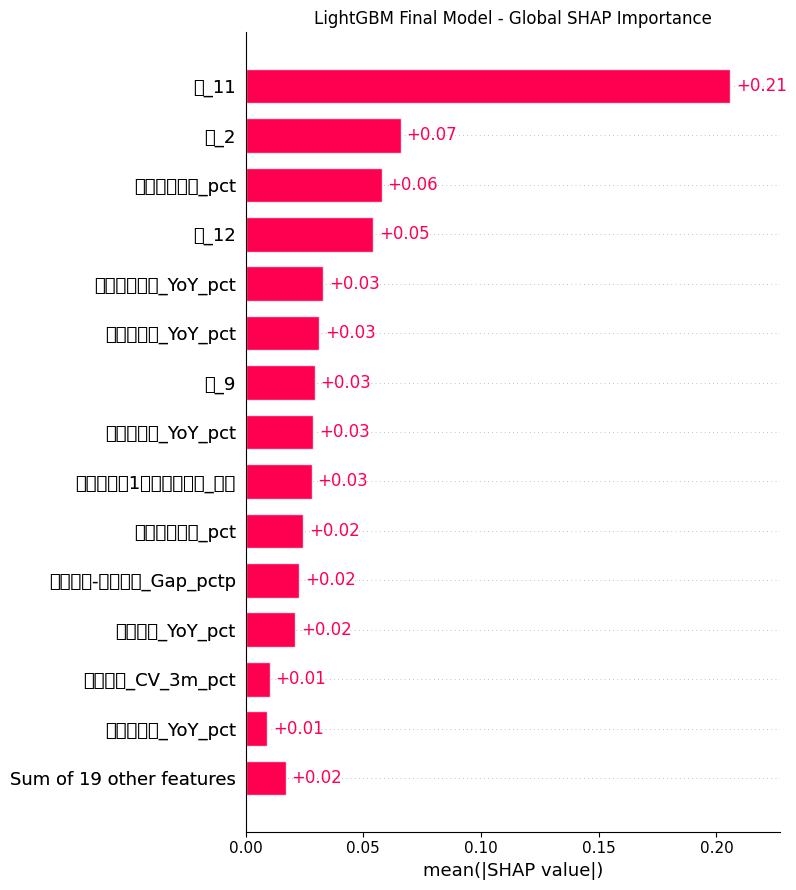

/tmp/ipykernel_1429/330802507.py:209: UserWarning:

Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:209: UserWarning:

Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:209: UserWarning:

Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:209: UserWarning:

Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:209: UserWarning:

Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:209: UserWarning:

Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:209: UserWarning:

Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1429/330802507.py:209: UserWarning:

Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.



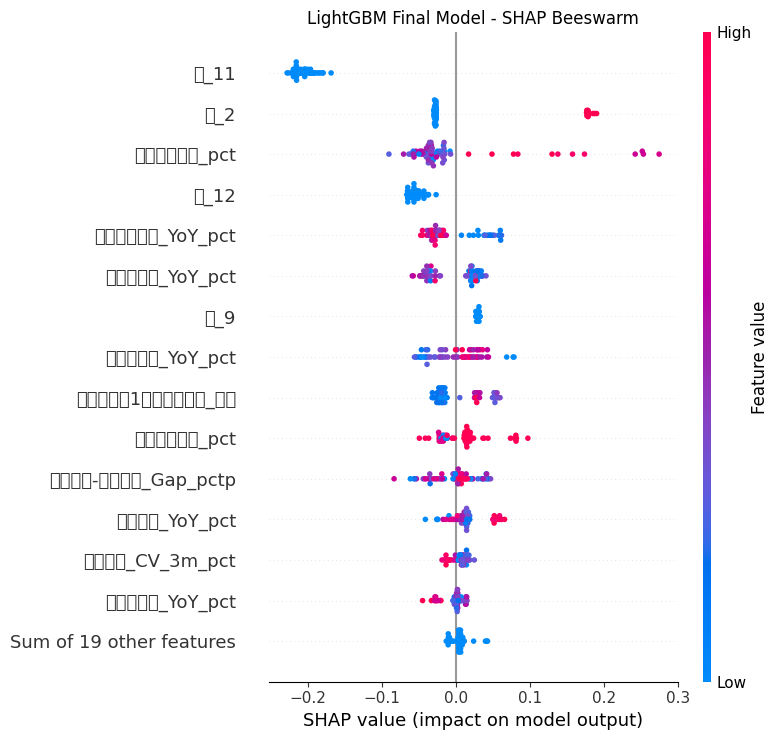

In [ ]:
# ============================================================
# STEP 19.
# Final LightGBM SHAP 분석
#
# 1) Global SHAP Importance
# 2) Beeswarm
#
# 최종 Test 64개 예측을 설명
# ============================================================

try:
    import shap
except ImportError:
    !pip install -q shap
    import shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Final LightGBM 내부 구성요소
# ============================================================

fitted_preprocessor = final_lgbm.named_steps['preprocess']
fitted_model = final_lgbm.named_steps['model']


# ============================================================
# 2. Final Test X 전처리
# ============================================================

X_test_transformed = fitted_preprocessor.transform(
    X_final_test
)


# sparse matrix라면 dense 변환
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()


# 실제 변환된 Feature 이름
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


# num__, cat__ 제거
clean_feature_names = [
    name
    .replace('num__', '')
    .replace('cat__', '')
    for name in feature_names
]


# SHAP에서 Feature 값을 표시할 DataFrame
X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=clean_feature_names,
    index=X_final_test.index
)


print("=" * 80)
print("1. SHAP DATA CHECK")
print("=" * 80)

print("Test 행 수 :", X_test_shap.shape[0])
print("Feature 수 :", X_test_shap.shape[1])

display(
    X_test_shap.head()
)


# ============================================================
# 3. TreeExplainer
# ============================================================

explainer = shap.TreeExplainer(
    fitted_model
)


shap_values = explainer(
    X_test_shap
)


print("\n" + "=" * 80)
print("2. SHAP VALUE CHECK")
print("=" * 80)

print(
    "SHAP shape :",
    shap_values.values.shape
)

print(
    "Expected value :",
    shap_values.base_values[0]
)


# ============================================================
# 4. Global SHAP Importance
#
# 평균 |SHAP|이 클수록
# 전체 Test 예측에 평균적으로 영향이 컸던 변수
# ============================================================

mean_abs_shap = np.abs(
    shap_values.values
).mean(axis=0)


shap_importance = pd.DataFrame({

    'Feature':
        clean_feature_names,

    'MeanAbsSHAP':
        mean_abs_shap
})


shap_importance = (

    shap_importance
    .sort_values(
        'MeanAbsSHAP',
        ascending=False
    )
    .reset_index(drop=True)
)


shap_importance['Importance_pct'] = (

    shap_importance['MeanAbsSHAP']

    / shap_importance['MeanAbsSHAP'].sum()

    * 100
)


print("\n" + "=" * 80)
print("3. GLOBAL SHAP IMPORTANCE")
print("=" * 80)

display(
    shap_importance
    .head(20)
    .round(4)
)


# ============================================================
# 5. SHAP Bar Plot
#
# 평균 |SHAP| 기준 전역 중요도
# ============================================================

plt.figure(figsize=(10, 7))

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    'LightGBM Final Model - Global SHAP Importance'
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. SHAP Beeswarm
#
# x축:
#   + → 폐업강도 예측을 높임
#   - → 폐업강도 예측을 낮춤
#
# 색:
#   빨강 → 해당 Feature 값이 높음
#   파랑 → 해당 Feature 값이 낮음
# ============================================================

plt.figure(figsize=(11, 8))

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    'LightGBM Final Model - SHAP Beeswarm'
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Colab Matplotlib 한글 폰트 설정
# ============================================================

!apt-get -qq update
!apt-get -qq install fonts-nanum
!fc-cache -fv > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 새로 설치한 폰트를 현재 세션에 다시 로드
fm._load_fontmanager(try_read_cache=False)

# NanumGothic 적용
mpl.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

print("현재 Matplotlib font :", mpl.rcParams['font.family'])

# 실제 설치 여부 확인
nanum_fonts = [
    f.name for f in fm.fontManager.ttflist
    if 'Nanum' in f.name
]

print("사용 가능한 Nanum 폰트:")
print(sorted(set(nanum_fonts)))

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118332 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
현재 Matplotlib font : ['NanumGothic']
사용 가능한 Nanum 폰트:
[]


발견된 폰트 파일 수 : 12
/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf
/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf
/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf
/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf
/usr/share/fonts/truetype/nanum/NanumSquareB.ttf
/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf
/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf
/usr/share/fonts/truetype/nanum/NanumGothic.ttf
/usr/share/fonts/truetype/nanum/NanumSquareR.ttf
/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf

사용할 폰트 경로 : /usr/share/fonts/truetype/nanum/NanumGothic.ttf
Matplotlib 폰트 이름 : NanumGothic


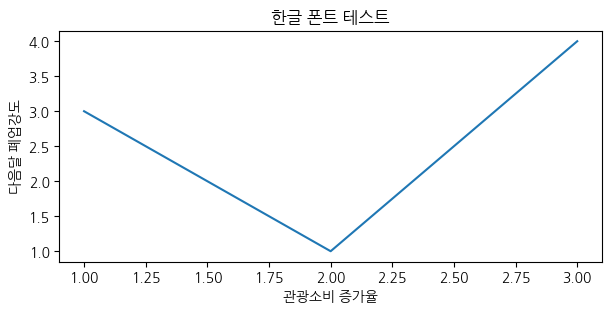

In [ ]:
# ============================================================
# Colab 한글 폰트 강제 등록
# ============================================================

import os
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


# 1. 설치된 Nanum 폰트 파일 실제 위치 확인
font_files = glob.glob(
    '/usr/share/fonts/truetype/nanum/*.ttf'
)

print("발견된 폰트 파일 수 :", len(font_files))

for f in font_files[:10]:
    print(f)


# 2. Matplotlib에 폰트 직접 등록
for font_file in font_files:
    fm.fontManager.addfont(font_file)


# 3. NanumGothic 실제 파일 찾기
nanum_gothic_candidates = [
    f for f in font_files
    if 'NanumGothic.ttf' in f
]

if len(nanum_gothic_candidates) == 0:
    raise FileNotFoundError(
        "NanumGothic.ttf 파일을 찾지 못했습니다."
    )

font_path = nanum_gothic_candidates[0]


# 4. 파일에서 실제 폰트 이름 읽기
font_name = fm.FontProperties(
    fname=font_path
).get_name()


print("\n사용할 폰트 경로 :", font_path)
print("Matplotlib 폰트 이름 :", font_name)


# 5. 전역 적용
mpl.rcParams['font.family'] = font_name
mpl.rcParams['axes.unicode_minus'] = False


# 6. 테스트
plt.figure(figsize=(7, 3))

plt.title('한글 폰트 테스트')
plt.plot([1, 2, 3], [3, 1, 4])

plt.xlabel('관광소비 증가율')
plt.ylabel('다음달 폐업강도')

plt.show()

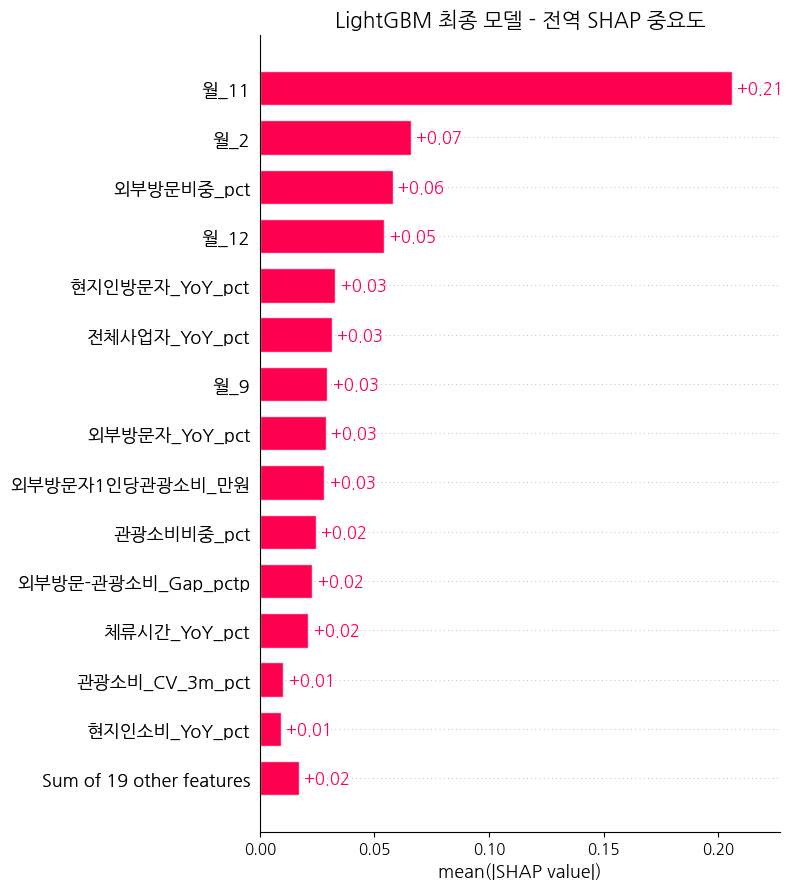

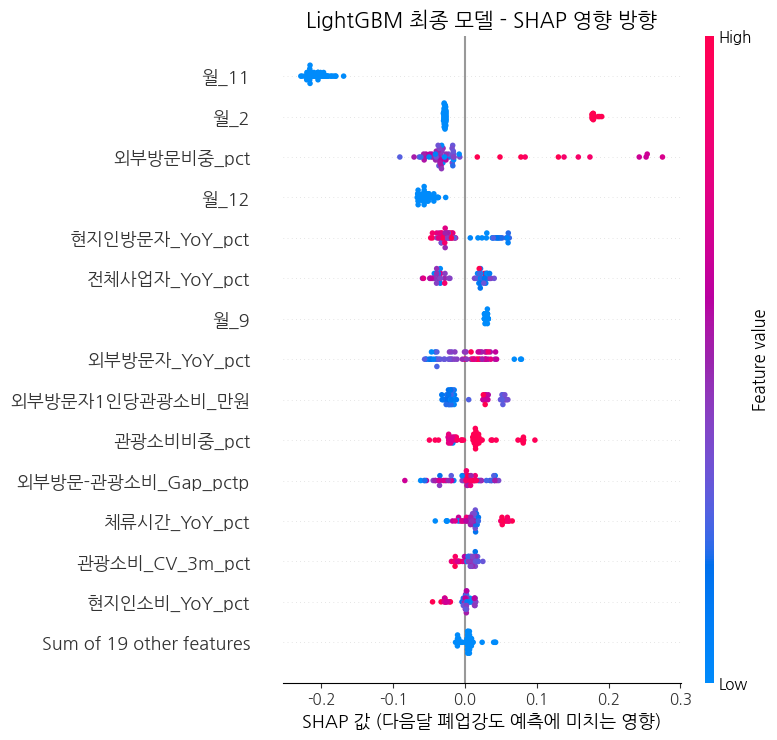

In [ ]:
# ============================================================
# SHAP 그래프 한글 폰트 적용 후 다시 출력
# ============================================================

import matplotlib.pyplot as plt
import matplotlib as mpl
import shap

mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False


# ------------------------------------------------------------
# 1. Global SHAP Importance
# ------------------------------------------------------------

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    'LightGBM 최종 모델 - 전역 SHAP 중요도',
    fontsize=15
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. SHAP Beeswarm
# ------------------------------------------------------------

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    'LightGBM 최종 모델 - SHAP 영향 방향',
    fontsize=15
)

plt.xlabel(
    'SHAP 값 (다음달 폐업강도 예측에 미치는 영향)'
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 20.
# 1) 계절변수 제외 SHAP 중요도
# 2) 핵심 변수 실제값 vs SHAP
# 3) 구간별 평균 SHAP으로 위험 전환 구간 탐색
#
# 기존 shap_values, clean_feature_names,
# X_final_test, final_test를 그대로 사용
# ============================================================

import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt


# ============================================================
# 1. SHAP 값을 DataFrame으로 변환
# ============================================================

shap_df = pd.DataFrame(
    shap_values.values,
    columns=clean_feature_names,
    index=X_final_test.index
)


print("=" * 80)
print("1. SHAP DATA CHECK")
print("=" * 80)

print("SHAP rows :", shap_df.shape[0])
print("SHAP features :", shap_df.shape[1])


# ============================================================
# 2. 계절변수 제외 Global SHAP Importance
#
# 월_* 제거
# ============================================================

nonseason_features = [
    col for col in clean_feature_names
    if not col.startswith('월_')
]


nonseason_importance = pd.DataFrame({
    'Feature': nonseason_features,
    'MeanAbsSHAP': [
        np.abs(shap_df[col]).mean()
        for col in nonseason_features
    ]
})


nonseason_importance = (
    nonseason_importance
    .sort_values(
        'MeanAbsSHAP',
        ascending=False
    )
    .reset_index(drop=True)
)


nonseason_importance['Importance_pct'] = (
    nonseason_importance['MeanAbsSHAP']
    /
    nonseason_importance['MeanAbsSHAP'].sum()
    * 100
)


print("\n" + "=" * 80)
print("2. NON-SEASON SHAP IMPORTANCE")
print("=" * 80)

display(
    nonseason_importance
    .head(15)
    .round(4)
)


# ============================================================
# 3. 계절 + 행정구까지 제외
#
# 관광/소비/사업자 변수만 따로 확인
# ============================================================

economic_features = [
    col for col in clean_feature_names
    if (
        not col.startswith('월_')
        and not col.startswith('행정구_')
    )
]


economic_importance = pd.DataFrame({
    'Feature': economic_features,
    'MeanAbsSHAP': [
        np.abs(shap_df[col]).mean()
        for col in economic_features
    ]
})


economic_importance = (
    economic_importance
    .sort_values(
        'MeanAbsSHAP',
        ascending=False
    )
    .reset_index(drop=True)
)


economic_importance['Importance_pct'] = (
    economic_importance['MeanAbsSHAP']
    /
    economic_importance['MeanAbsSHAP'].sum()
    * 100
)


print("\n" + "=" * 80)
print("3. TOURISM / CONSUMPTION / BUSINESS SHAP")
print("=" * 80)

display(
    economic_importance.round(4)
)


# ============================================================
# 4. 관광·경제 변수만 SHAP 중요도 그래프
# ============================================================

plot_imp = (
    economic_importance
    .head(15)
    .sort_values('MeanAbsSHAP')
)


fig = px.bar(
    plot_imp,
    x='MeanAbsSHAP',
    y='Feature',
    orientation='h',
    text='MeanAbsSHAP',
    title='계절효과 제외 - 관광·소비·사업자 SHAP 중요도'
)


fig.update_traces(
    texttemplate='%{text:.3f}'
)


fig.update_layout(
    xaxis_title='평균 |SHAP 값|',
    yaxis_title='변수',
    width=950,
    height=650
)

fig.show()


# ============================================================
# 5. 핵심 Dependence 변수
# ============================================================

core_features = [
    '외부방문비중_pct',
    '현지인방문자_YoY_pct',
    '전체사업자_YoY_pct',
    '외부방문자1인당관광소비_만원'
]


# 존재 여부 확인
for col in core_features:
    if col not in shap_df.columns:
        print("SHAP에 없는 변수 :", col)

    if col not in X_final_test.columns:
        print("원본 X에 없는 변수 :", col)


# ============================================================
# 6. 변수별 실제값 ↔ SHAP Scatter
#
# SHAP > 0
# → 다음달 폐업강도 예측을 높이는 방향
#
# SHAP < 0
# → 다음달 폐업강도 예측을 낮추는 방향
# ============================================================

dependence_data = {}


for feature in core_features:

    temp = pd.DataFrame({

        'FeatureValue':
            X_final_test[feature].values,

        'SHAP':
            shap_df[feature].values,

        '행정구':
            final_test['행정구'].values,

        'FeatureMonth':
            final_test['연월'].values,

        'TargetMonth':
            final_test['다음달_연월'].values,

        'Actual':
            y_final_test.values,

        'Predicted':
            test_pred
    })


    dependence_data[feature] = temp


    fig = px.scatter(
        temp,
        x='FeatureValue',
        y='SHAP',

        hover_data=[
            '행정구',
            'FeatureMonth',
            'TargetMonth',
            'Actual',
            'Predicted'
        ],

        title=f'{feature} - 실제값에 따른 SHAP 영향'
    )


    # SHAP = 0 기준선
    fig.add_hline(
        y=0,
        line_dash='dash'
    )


    fig.update_layout(
        xaxis_title=feature,
        yaxis_title='SHAP 값 (+ : 폐업강도 예측 상승)',
        width=850,
        height=550
    )


    fig.show()


# ============================================================
# 7. 각 변수를 5개 분위구간으로 나눠
# 평균 SHAP 확인
#
# hard threshold를 만드는 것이 아니라
# 위험 방향이 바뀌는 구간 탐색용
# ============================================================

all_bin_results = []


for feature in core_features:

    temp = dependence_data[feature].copy()


    # 같은 값이 많을 경우 duplicates='drop'
    temp['구간'] = pd.qcut(
        temp['FeatureValue'],
        q=5,
        duplicates='drop'
    )


    bin_summary = (
        temp
        .groupby(
            '구간',
            observed=True
        )
        .agg(
            관측수=('SHAP', 'count'),
            실제값_최소=('FeatureValue', 'min'),
            실제값_중앙=('FeatureValue', 'median'),
            실제값_최대=('FeatureValue', 'max'),
            평균_SHAP=('SHAP', 'mean'),
            SHAP_양수비율=('SHAP', lambda x: (x > 0).mean())
        )
        .reset_index()
    )


    bin_summary['Feature'] = feature


    all_bin_results.append(
        bin_summary
    )


    print("\n" + "=" * 80)
    print(f"4. BINNED SHAP : {feature}")
    print("=" * 80)

    display(
        bin_summary[
            [
                '관측수',
                '실제값_최소',
                '실제값_중앙',
                '실제값_최대',
                '평균_SHAP',
                'SHAP_양수비율'
            ]
        ].round(4)
    )


binned_shap_summary = pd.concat(
    all_bin_results,
    ignore_index=True
)

1. SHAP DATA CHECK
SHAP rows : 64
SHAP features : 33

2. NON-SEASON SHAP IMPORTANCE


,Feature,MeanAbsSHAP,Importance_pct
0,외부방문비중_pct,0.0579,21.1935
1,현지인방문자_YoY_pct,0.0329,12.0589
2,전체사업자_YoY_pct,0.0314,11.4835
3,외부방문자_YoY_pct,0.0287,10.5004
4,외부방문자1인당관광소비_만원,0.0280,10.2546
5,관광소비비중_pct,0.0245,8.9516
6,외부방문-관광소비_Gap_pctp,0.0228,8.3510
7,체류시간_YoY_pct,0.0210,7.7025
8,관광소비_CV_3m_pct,0.0102,3.7217
9,현지인소비_YoY_pct,0.0091,3.3453



3. TOURISM / CONSUMPTION / BUSINESS SHAP


,Feature,MeanAbsSHAP,Importance_pct
0,외부방문비중_pct,0.0579,21.5012
1,현지인방문자_YoY_pct,0.0329,12.2339
2,전체사업자_YoY_pct,0.0314,11.6502
3,외부방문자_YoY_pct,0.0287,10.6528
4,외부방문자1인당관광소비_만원,0.0280,10.4034
5,관광소비비중_pct,0.0245,9.0815
6,외부방문-관광소비_Gap_pctp,0.0228,8.4723
7,체류시간_YoY_pct,0.0210,7.8143
8,관광소비_CV_3m_pct,0.0102,3.7757
9,현지인소비_YoY_pct,0.0091,3.3939



4. BINNED SHAP : 외부방문비중_pct


...

,관측수,실제값_최소,실제값_중앙,실제값_최대,평균_SHAP,SHAP_양수비율
0,13,-2.7216,-0.4298,0.8240,0.0387,1.0000
1,13,0.9791,1.8284,3.3855,0.0215,0.6154
2,12,3.4864,4.3256,5.1196,-0.0271,0.0000
3,13,5.3779,6.4157,7.4372,-0.0272,0.0000
4,13,7.7209,8.7685,17.6236,-0.0295,0.0000



4. BINNED SHAP : 전체사업자_YoY_pct


,관측수,실제값_최소,실제값_중앙,실제값_최대,평균_SHAP,SHAP_양수비율
0,13,-1.8003,-1.3787,-1.1157,0.0110,0.7692
1,13,-1.0997,-0.8674,-0.5304,0.0220,0.9231
2,12,-0.4684,0.0744,0.2632,0.0148,0.8333
3,13,0.2633,0.4452,0.8850,-0.0291,0.0769
4,13,0.9135,1.9824,4.7166,-0.0236,0.3077



4. BINNED SHAP : 외부방문자1인당관광소비_만원


,관측수,실제값_최소,실제값_중앙,실제값_최대,평균_SHAP,SHAP_양수비율
0,13,0.4603,0.6711,1.0140,-0.0172,0.0000
1,13,1.0150,1.0887,1.1547,-0.0244,0.0000
2,12,1.1598,1.2649,1.3540,-0.0229,0.0000
3,13,1.3962,1.6527,2.0230,0.0392,0.8462
4,13,2.1811,2.9296,4.8654,0.0303,1.0000


In [ ]:
# ============================================================
# STEP 21.
# 가설 2·3·6 핵심 변수 SHAP 상세 분석
#
# 1. 실제값 vs SHAP 산점도
# 2. 실제값 ↔ SHAP Spearman
# 3. 5분위 구간별 평균 SHAP
# 4. SHAP 부호 전환 후보구간 탐색
# ============================================================

import numpy as np
import pandas as pd
import plotly.express as px

from scipy.stats import spearmanr


# ============================================================
# 1. 분석할 변수
# ============================================================

hypothesis_features = {

    '외부방문-관광소비_Gap_pctp':
        '가설2_소비전환실패',

    '관광소비비중_pct':
        '가설3_관광산업편중',

    '체류시간_YoY_pct':
        '체류시간변화',

    '외부방문자_YoY_pct':
        '관광객증가'
}


# ============================================================
# 2. 컬럼 존재 여부 확인
# ============================================================

print("=" * 80)
print("1. FEATURE CHECK")
print("=" * 80)

for feature in hypothesis_features:

    shap_exists = feature in shap_df.columns
    x_exists = feature in X_final_test.columns

    print(
        feature,
        "| SHAP:", shap_exists,
        "| Original X:", x_exists
    )


# ============================================================
# 3. 분석 결과 저장
# ============================================================

detail_data = {}
bin_results = []
direction_results = []


# ============================================================
# 4. 변수별 분석
# ============================================================

for feature, hypothesis_name in hypothesis_features.items():

    temp = pd.DataFrame({

        'FeatureValue':
            X_final_test[feature].values,

        'SHAP':
            shap_df[feature].values,

        '행정구':
            final_test['행정구'].values,

        'FeatureMonth':
            final_test['연월'].values,

        'TargetMonth':
            final_test['다음달_연월'].values,

        'Actual':
            y_final_test.values,

        'Predicted':
            test_pred
    })


    detail_data[feature] = temp


    # ========================================================
    # A. 실제값 ↔ SHAP Spearman
    # ========================================================

    rho, pvalue = spearmanr(
        temp['FeatureValue'],
        temp['SHAP']
    )


    direction_results.append({

        'Feature':
            feature,

        '가설':
            hypothesis_name,

        'Value_SHAP_Spearman':
            rho,

        'p_value':
            pvalue,

        'MeanAbsSHAP':
            np.abs(temp['SHAP']).mean(),

        'MeanSHAP':
            temp['SHAP'].mean()
    })


    # ========================================================
    # B. Scatter Plot
    # ========================================================

    fig = px.scatter(

        temp,

        x='FeatureValue',
        y='SHAP',

        hover_data=[
            '행정구',
            'FeatureMonth',
            'TargetMonth',
            'Actual',
            'Predicted'
        ],

        title=(
            f'{feature} - 실제값에 따른 SHAP 영향'
        )
    )


    fig.add_hline(
        y=0,
        line_dash='dash'
    )


    fig.update_layout(

        xaxis_title=feature,

        yaxis_title=(
            'SHAP 값 '
            '(+ : 다음달 폐업강도 예측 상승)'
        ),

        width=850,
        height=550
    )


    fig.show()


    # ========================================================
    # C. 5분위 구간
    # ========================================================

    temp['구간'] = pd.qcut(
        temp['FeatureValue'],
        q=5,
        duplicates='drop'
    )


    bin_summary = (

        temp

        .groupby(
            '구간',
            observed=True
        )

        .agg(

            관측수=(
                'SHAP',
                'count'
            ),

            실제값_최소=(
                'FeatureValue',
                'min'
            ),

            실제값_중앙=(
                'FeatureValue',
                'median'
            ),

            실제값_최대=(
                'FeatureValue',
                'max'
            ),

            평균_SHAP=(
                'SHAP',
                'mean'
            ),

            중앙_SHAP=(
                'SHAP',
                'median'
            ),

            SHAP_양수비율=(
                'SHAP',
                lambda x: (x > 0).mean()
            )
        )

        .reset_index()
    )


    bin_summary['Feature'] = feature
    bin_summary['가설'] = hypothesis_name


    bin_results.append(
        bin_summary
    )


    print("\n" + "=" * 80)
    print(
        f"2. BINNED SHAP : {feature}"
    )
    print("=" * 80)

    display(

        bin_summary[
            [
                '관측수',
                '실제값_최소',
                '실제값_중앙',
                '실제값_최대',
                '평균_SHAP',
                '중앙_SHAP',
                'SHAP_양수비율'
            ]
        ]

        .round(4)
    )


# ============================================================
# 5. 실제값 ↔ SHAP 방향성 요약
# ============================================================

direction_summary = pd.DataFrame(
    direction_results
)


direction_summary = (

    direction_summary

    .sort_values(
        'MeanAbsSHAP',
        ascending=False
    )

    .reset_index(drop=True)
)


print("\n" + "=" * 80)
print("3. VALUE ↔ SHAP DIRECTION SUMMARY")
print("=" * 80)

display(
    direction_summary.round(4)
)


# ============================================================
# 6. 모든 5분위 결과 통합
# ============================================================

hypothesis_bin_summary = pd.concat(
    bin_results,
    ignore_index=True
)


# ============================================================
# 7. SHAP 부호 전환 후보 구간 탐색
#
# 앞 구간 평균 SHAP과 다음 구간 평균 SHAP의
# 부호가 달라지는 위치 확인
#
# ※ 통계적 임계값이 아니라
#    모델상의 탐색적 전환구간
# ============================================================

transition_rows = []


for feature in hypothesis_features:

    temp_bins = (
        hypothesis_bin_summary[
            hypothesis_bin_summary['Feature']
            ==
            feature
        ]
        .reset_index(drop=True)
    )


    for i in range(
        len(temp_bins) - 1
    ):

        current_shap = (
            temp_bins.loc[
                i,
                '평균_SHAP'
            ]
        )

        next_shap = (
            temp_bins.loc[
                i + 1,
                '평균_SHAP'
            ]
        )


        # 부호가 서로 다르면
        if (
            np.sign(current_shap)
            !=
            np.sign(next_shap)
        ):

            transition_rows.append({

                'Feature':
                    feature,

                '이전구간_최대':
                    temp_bins.loc[
                        i,
                        '실제값_최대'
                    ],

                '다음구간_최소':
                    temp_bins.loc[
                        i + 1,
                        '실제값_최소'
                    ],

                '이전_평균SHAP':
                    current_shap,

                '다음_평균SHAP':
                    next_shap
            })


transition_df = pd.DataFrame(
    transition_rows
)


print("\n" + "=" * 80)
print("4. SHAP SIGN TRANSITION CANDIDATES")
print("=" * 80)


if len(transition_df) == 0:

    print(
        "평균 SHAP 부호가 바뀌는 "
        "5분위 경계가 없습니다."
    )

else:

    display(
        transition_df.round(4)
    )

1. FEATURE CHECK
외부방문-관광소비_Gap_pctp | SHAP: True | Original X: True
관광소비비중_pct | SHAP: True | Original X: True
체류시간_YoY_pct | SHAP: True | Original X: True
외부방문자_YoY_pct | SHAP: True | Original X: True



2. BINNED SHAP : 외부방문-관광소비_Gap_pctp


,관측수,실제값_최소,실제값_중앙,실제값_최대,평균_SHAP,중앙_SHAP,SHAP_양수비율
0,13,-23.7055,-17.3362,-14.3349,-0.0076,-0.0038,0.3846
1,13,-13.5486,-9.5432,-7.2481,0.0035,-0.0011,0.4615
2,12,-7.2133,-6.1852,-4.1435,0.0077,0.0048,0.7500
3,13,-4.0114,-1.6038,2.1087,-0.0245,-0.0258,0.3077
4,13,2.1732,3.5544,10.8143,0.0067,0.0072,0.8462



2. BINNED SHAP : 관광소비비중_pct


,관측수,실제값_최소,실제값_중앙,실제값_최대,평균_SHAP,중앙_SHAP,SHAP_양수비율
0,13,76.5793,94.8902,95.8259,-0.0182,-0.0183,0.0000
1,13,95.8499,98.7279,99.0650,-0.0153,-0.0152,0.0769
2,12,99.0892,99.1618,99.4121,0.0380,0.0231,1.0000
3,13,99.4222,99.4854,99.5619,0.0316,0.0175,1.0000
4,13,99.5706,99.6287,99.7541,0.0144,0.0147,1.0000


...

,관측수,실제값_최소,실제값_중앙,실제값_최대,평균_SHAP,중앙_SHAP,SHAP_양수비율
0,13,-7.6336,-1.1327,1.1047,-0.0183,-0.0436,0.2308
1,13,1.4357,2.8532,4.3162,-0.0310,-0.0293,0.0000
2,12,4.5504,5.5998,7.4814,-0.0036,-0.0020,0.4167
3,13,7.7073,9.2545,11.6194,0.0301,0.0296,1.0000
4,13,11.6742,15.5396,23.8491,0.0180,0.0164,0.9231



3. VALUE ↔ SHAP DIRECTION SUMMARY


,Feature,가설,Value_SHAP_Spearman,p_value,MeanAbsSHAP,MeanSHAP
0,외부방문자_YoY_pct,관광객증가,0.5927,0.0000,0.0287,-0.0009
1,관광소비비중_pct,가설3_관광산업편중,0.6121,0.0000,0.0245,0.0097
2,외부방문-관광소비_Gap_pctp,가설2_소비전환실패,0.0598,0.6389,0.0228,-0.0030
3,체류시간_YoY_pct,체류시간변화,0.2451,0.0509,0.0210,0.0154



4. SHAP SIGN TRANSITION CANDIDATES


,Feature,이전구간_최대,다음구간_최소,이전_평균SHAP,다음_평균SHAP
0,외부방문-관광소비_Gap_pctp,-14.3349,-13.5486,-0.0076,0.0035
1,외부방문-관광소비_Gap_pctp,-4.1435,-4.0114,0.0077,-0.0245
2,외부방문-관광소비_Gap_pctp,2.1087,2.1732,-0.0245,0.0067
3,관광소비비중_pct,99.0650,99.0892,-0.0153,0.0380
4,체류시간_YoY_pct,1.0194,1.0321,0.0105,-0.0011
5,체류시간_YoY_pct,4.5428,5.2361,-0.0011,0.0521
6,외부방문자_YoY_pct,7.4814,7.7073,-0.0036,0.0301


In [ ]:
# ============================================================
# STEP 22.
# SHAP 기반 위험신호 중첩 지역 탐색
#
# ※ 모델 재학습 X
# ※ Test 성능 선택 X
# ※ 설명/진단 목적
# ============================================================

import pandas as pd
import numpy as np


risk_df = final_test[
    [
        '연월',
        '다음달_연월',
        '행정구',

        '외부방문비중_pct',
        '외부방문자_YoY_pct',
        '현지인방문자_YoY_pct',
        '전체사업자_YoY_pct',
        '외부방문자1인당관광소비_만원',
        '관광소비비중_pct',
        '체류시간_YoY_pct'
    ]
].copy()


# ============================================================
# 실제 / 예측 Y
# ============================================================

risk_df['실제_폐업강도'] = (
    y_final_test.values
)

risk_df['예측_폐업강도'] = (
    test_pred
)

risk_df['절대오차'] = abs(
    risk_df['실제_폐업강도']
    -
    risk_df['예측_폐업강도']
)


# ============================================================
# SHAP 분석에서 발견한 탐색적 위험조건
# ============================================================

risk_df['R1_외부방문의존'] = (
    risk_df['외부방문비중_pct']
    >= 56.5
)

risk_df['R2_외부방문급증'] = (
    risk_df['외부방문자_YoY_pct']
    >= 7.7
)

risk_df['R3_현지인방문약화'] = (
    risk_df['현지인방문자_YoY_pct']
    < 3.5
)

risk_df['R4_사업자성장정체'] = (
    risk_df['전체사업자_YoY_pct']
    < 0.3
)

risk_df['R5_고관광객소비'] = (
    risk_df['외부방문자1인당관광소비_만원']
    >= 1.4
)

risk_df['R6_관광소비편중'] = (
    risk_df['관광소비비중_pct']
    >= 99.1
)

risk_df['R7_체류급증'] = (
    risk_df['체류시간_YoY_pct']
    >= 5.2
)


risk_columns = [
    'R1_외부방문의존',
    'R2_외부방문급증',
    'R3_현지인방문약화',
    'R4_사업자성장정체',
    'R5_고관광객소비',
    'R6_관광소비편중',
    'R7_체류급증'
]


# ============================================================
# 위험신호 개수
# ============================================================

risk_df['위험신호수'] = (
    risk_df[risk_columns]
    .sum(axis=1)
)


# ============================================================
# 위험신호수 기준 정렬
# ============================================================

risk_rank = (

    risk_df

    .sort_values(
        [
            '위험신호수',
            '예측_폐업강도'
        ],
        ascending=[
            False,
            False
        ]
    )

    .reset_index(drop=True)
)


print("=" * 90)
print("1. SHAP-BASED RISK SIGNAL RANKING")
print("=" * 90)

display(
    risk_rank[
        [
            '연월',
            '다음달_연월',
            '행정구',
            '위험신호수',
            '실제_폐업강도',
            '예측_폐업강도',
            '절대오차'
        ]
    ]
    .head(30)
    .round(4)
)


# ============================================================
# 위험조건 상세
# ============================================================

print("\n" + "=" * 90)
print("2. TOP 15 RISK SIGNAL DETAILS")
print("=" * 90)

display(
    risk_rank[
        [
            '연월',
            '행정구',
            '위험신호수'
        ]
        +
        risk_columns
        +
        [
            '실제_폐업강도',
            '예측_폐업강도'
        ]
    ]
    .head(15)
)


# ============================================================
# 위험신호 개수별 실제 폐업강도
# ============================================================

signal_summary = (

    risk_df

    .groupby('위험신호수')

    .agg(
        관측수=('행정구', 'count'),

        실제폐업강도_평균=(
            '실제_폐업강도',
            'mean'
        ),

        예측폐업강도_평균=(
            '예측_폐업강도',
            'mean'
        ),

        실제폐업강도_중앙값=(
            '실제_폐업강도',
            'median'
        )
    )

    .reset_index()
)


print("\n" + "=" * 90)
print("3. RISK SIGNAL COUNT vs ACTUAL CLOSURE")
print("=" * 90)

display(
    signal_summary.round(4)
)

1. SHAP-BASED RISK SIGNAL RANKING


,연월,다음달_연월,행정구,위험신호수,실제_폐업강도,예측_폐업강도,절대오차
0,202602,202603,북구,6,2.1271,2.3679,0.2408
1,202602,202603,연제구,6,2.3999,2.2924,0.1076
2,202602,202603,강서구,5,2.8492,2.5419,0.3073
3,202601,202602,강서구,5,1.9575,2.3693,0.4119
4,202602,202603,사상구,5,2.7231,2.3540,0.3691
5,202603,202604,강서구,5,2.0464,2.2707,0.2243
6,202602,202603,동구,5,2.2825,2.2252,0.0573
7,202604,202605,사상구,5,2.1678,2.0867,0.0811
8,202604,202605,북구,5,1.8865,2.0742,0.1877
9,202604,202605,강서구,4,2.3644,2.2747,0.0897



2. TOP 15 RISK SIGNAL DETAILS


,연월,행정구,위험신호수,R1_외부방문의존,R2_외부방문급증,R3_현지인방문약화,R4_사업자성장정체,R5_고관광객소비,R6_관광소비편중,R7_체류급증,실제_폐업강도,예측_폐업강도
0,202602,북구,6,False,True,True,True,True,True,True,2.127089,2.367932
1,202602,연제구,6,True,True,True,True,False,True,True,2.399936,2.292359
2,202602,강서구,5,True,True,True,False,True,True,False,2.849228,2.541943
3,202601,강서구,5,True,True,False,False,True,True,True,1.957472,2.369325
4,202602,사상구,5,False,True,True,True,True,True,False,2.723119,2.353974
5,202603,강서구,5,True,True,False,False,True,True,True,2.046438,2.270733
6,202602,동구,5,True,False,True,True,False,True,True,2.282496,2.225162
7,202604,사상구,5,False,False,True,True,True,True,True,2.167819,2.086689
8,202604,북구,5,False,False,True,True,True,True,True,1.886455,2.074185
9,202604,강서구,4,True,True,False,False,True,True,False,2.364436,2.274732



3. RISK SIGNAL COUNT vs ACTUAL CLOSURE


,위험신호수,관측수,실제폐업강도_평균,예측폐업강도_평균,실제폐업강도_중앙값
0,0,2,1.7233,1.7511,1.7233
1,1,12,1.9031,1.8389,1.8990
2,2,13,1.8639,1.8709,1.8307
3,3,17,1.9611,1.9922,1.9351
4,4,11,1.9621,2.0758,2.0003
5,5,7,2.2733,2.2746,2.1678
6,6,2,2.2635,2.3301,2.2635
